## Tarea 3 (2026) - Bastián Fierro Cabezas

# Respuestas

## Pregunta 1

**Enunciado: Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.**

---

- **Dataset inicial.** El dataset original tiene 41.854 filas (observaciones) y 24
  columnas. La columna de texto generado por el cuestionario llega con el nombre
  `resumen_sk`, que se renombra a `narrative` para que sea consistente con el diccionario
  de datos del enunciado. De las variables disponibles:

    - `sexo`, `area`, `madre_work`, `vive_padre`, `vive_madre` son categóricas/binarias
      (esta última con un detalle no estrictamente binario, ver más abajo).
    - `sk1`-`sk13` y `act_fisica` son escalas ordinales tipo Likert (1 a 5).
    - `edad` (en meses), `imce` (z-score), `educm` y `educp` (años de escolaridad) son
      variables continuas.

- **Datos faltantes.** Solo dos variables presentan valores `NaN`: `act_fisica` (1.435
  casos,  $\approx$ 3.4%) y `educm` (551 casos,  $\approx$ 1.3%). Se imputó `act_fisica` con la **moda** (=3.0,
  por ser ordinal) y `educm` con la **mediana** (=13.0, por ser continua), dejando
  indicadores `*_missing` para trazabilidad. No se detectaron códigos de "missing
  disfrazado" (p. ej. -99) en el resto de las variables.

- **Recodificación de `vive_padre`/`vive_madre`.** El diccionario define una codificación
  no estrictamente binaria (1=vive, 2=más de un padre/madre). Como la categoría 2 es
  minoritaria (16 y 70 casos respectivamente), se colapsó 2 $\rightarrow$ 1 para obtener un indicador
  binario de presencia, conservando el dato original en columnas `_raw`.

- **Duplicados y outliers.** Se eliminaron 15 registros exactamente duplicados (0.036% de
  la muestra). Se revisó `imce` con criterio de 3×IQR (sin outliers extremos) y contra el
  límite convencional OMS de $\pm$ 5 desviaciones estándar (solo 13 casos al límite,  $\approx$ 0.03%);
  no se eliminó ninguna observación, ya que el dataset llega pre-truncado en ese rango. Se
  confirmó que `sk1`-`sk13` están estrictamente en el rango [1,5] esperado.

Finalmente, nos quedamos con una base limpia de **41.839 filas $\times$ 28 columnas** (24
originales + `narrative` renombrada + 4 columnas auxiliares de trazabilidad), lista para
los análisis de las preguntas siguientes.


## Pregunta 2

**Enunciado: A partir de las variables sk1-sk13 realice un EFA. En particular determine el numero optimo de factores y reporte las variables que se asocian a cada factor (usando los factor loadings). Tambien discuta si existen variables que no son informativas. (Hint: para realizar un EFA, todas las variables deben estar representatadas en el mismo sentido logico. Si una carateristica es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).**

---

Se realizó un **Análisis Factorial Exploratorio (EFA)** sobre las 13 variables `sk1`-`sk13`.

- **Inversión de escala.** `sk7` ("es agresivo") está codificada en sentido inverso al
  resto (1=nunca, 5=siempre, mientras que las demás usan 1=siempre, 5=nunca como
  comportamiento positivo). Se invirtió con `sk7_inv = 6 - sk7` para que todas las
  variables apunten en el mismo sentido lógico.

- **Adecuación muestral.** El test de Bartlett rechaza contundentemente H0 (p $\approx$ 0) y el
  **KMO global es 0.873** ("muy bueno" para EFA). `sk7_inv` tiene el KMO individual más
  bajo del conjunto (0.788), una primera señal de que aporta menos al constructo común.

- **Número óptimo de factores.** El criterio de Kaiser (autovalor > 1) sobre los
  autovalores sin rotación sugiere **3 factores** (el cuarto autovalor es  $\approx$ 1.00, justo en
  el límite), consistente con un quiebre claro en el *scree plot*. Como contraste, se probó
  `semopy.efa.explore_cfa_model()`, que sugiere 4 factores pero con variables compartidas
  entre varios de ellos (solución inestable por alta colinealidad). Se prefirió la
  solución de 3 factores por ser más limpia e interpretable.

- **Estructura resultante (rotación Varimax):**
    - **Factor 1 (Curiosidad/Cognición):** `sk9`, `sk10`, `sk11`, `sk12`, `sk13`.
    - **Factor 2 (Afecto):** `sk1`, `sk2`, `sk3`, `sk4`.
    - **Factor 3 (Interacción social):** `sk5`, `sk6`, `sk8`.
    - Los 3 factores explican conjuntamente  $\approx$ 37.2% de la varianza total.

- **Variable no informativa: `sk7` (agresividad).** Tres evidencias convergentes:
  (i) tras invertir su escala, correlaciona con el signo correcto pero con magnitud
  notoriamente más débil (|r| $\approx$ 0.09) que el resto de las variables entre sí (0.20-0.35);
  (ii) KMO individual más bajo (0.788); (iii) comunalidad casi nula ( $\approx$ 0.03 vs. 0.29-0.60
  del resto) y *loadings* por debajo del umbral de pertenencia (0.40) en los tres factores.
  Excluirla mejora la varianza explicada acumulada (37.2% $\rightarrow$ 40.3%) sin alterar la estructura
  de los otros factores. Se decide **excluir `sk7`** del CFA de la Pregunta 3.


## Pregunta 3

**Enunciado: Con los resultados obtenidos en la Pregunta 2, proponga un CFA donde cada variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto comun entre las variables incluidas. Reporte la importancia de cada medida (variable) a cada factor e indique la correlacion entre factores (loadings). Guarde sus predicciones.**

---

A partir de los resultados del EFA, se especificó un **CFA** con 3 factores donde cada
variable se asocia exclusivamente a un único factor (sin `sk7`).

| Factor | Concepto común | Variables |
|---|---|---|
| **Afecto** | Expresión afectivo-emocional hacia padres y pares | `sk1`, `sk2`, `sk3`, `sk4` |
| **Interaccion_Social** | Interacción social y juego cooperativo | `sk5`, `sk6`, `sk8` |
| **Curiosidad** | Curiosidad e intereses cognitivos | `sk9`, `sk10`, `sk11`, `sk12`, `sk13` |

- **Importancia de cada medida (*loadings* estandarizados):** todos positivos,
  significativos (p $\approx$ 0.000) y de magnitud moderada-alta (0.46-0.74). Las medidas más
  representativas de cada factor son `sk4` (0.72) en Afecto, `sk5` (0.72) en Interacción
  Social, y `sk11` (0.74) en Curiosidad; ninguna medida tiene un *loading* débil (<0.40)
  que cuestione su asignación.

- **Correlación entre factores:** los tres correlacionan positiva, moderada y
  significativamente entre sí (entre 0.60 y 0.66), coherente con ser dimensiones
  distintas pero relacionadas de un mismo desarrollo socioemocional general, sin ser redundantes entre sí.

- **Ajuste del modelo:** CFI $\approx$ 0.95, TLI $\approx$ 0.93, RMSEA $\approx$ 0.053 (buen ajuste según los criterios
  convencionales). Como verificación adicional, se comparó contra un modelo alternativo de
  1 solo factor general: ese modelo tiene un ajuste claramente peor (CFI=0.80, RMSEA=0.103),
  lo que respalda empíricamente la estructura de 3 factores frente a una más simple.

- **Predicciones guardadas:** se calcularon los *factor scores* (`Afecto_score`,
  `Interaccion_Social_score`, `Curiosidad_score`) vía `model.predict_factors()` y se incorporaron al dataframe principal, quedando como *features* de entrada para el modelo de clasificación de la Pregunta 4.


## Pregunta 4

**Enunciado: Usando los features del modelo de la Pregunta 3, entrene un modelo Random Forest para clasificar la muestra usando la variable madre_work como target. Para facilitar el problema, excluya las personas desempleadas (categoria minoritaria). Recuerde tanto la optimizacion de hiperpametros como la validacion de pliegues (k-fold).**

---

Se entrenó un **Random Forest** para clasificar `madre_work` usando los 3 *factor scores*
del CFA como *features*, siguiendo el enunciado actualizado que indica **excluir las personas
desempleadas** (categoría minoritaria, ~10 % de la muestra). Esto convierte el problema de
clasificación multiclase original (3 categorías: -1, 0, 1) en un problema **binario**: labor
doméstica (`-1`) vs. empleada (`1`), con ~37.500 observaciones.

- **Implicancia del cambio de planteamiento.** Excluir la clase `0` recalibra el **baseline
  de referencia**: ya no es 0.333 (azar uniforme entre 3 clases), sino  $\approx$ 0.55 (proporción
  de la clase mayoritaria entre las dos restantes). Cualquier modelo que no supere ese umbral
  es indistinguible de "predecir siempre la clase más frecuente". También cambia el conjunto
  de métricas relevantes: con 2 clases tiene sentido reportar **ROC-AUC** (área bajo la curva
  ROC), que evalúa la capacidad del modelo de ordenar correctamente los casos de ambas clases
  con independencia del umbral de clasificación.

- **Protocolo de entrenamiento.** Se reservó un 20 % de la muestra binaria como test
  estratificado (proporciones de clase preservadas). El 80 % restante se usó para
  `GridSearchCV` + `StratifiedKFold` (5 pliegues), optimizando `f1_macro`. Se añadió
  `class_weight='balanced'` para compensar el leve desbalance residual (~45/55 %).
  Hiperparámetros explorados: `n_estimators`  $\in$  {100, 200}, `max_depth`  $\in$  {6, 10, None},
  `min_samples_leaf`  $\in$  {5, 20} (12 combinaciones × 5 folds = 60 ajustes).

- **Desempeño.** Accuracy y macro-F1 cercanos al baseline (~0.55 y ~0.51-0.52
  respectivamente); ROC-AUC próximo a 0.5. El modelo optimizado mejora marginalmente
  respecto al *benchmark* sin ajustar, pero no supera el umbral de forma sustantiva. Esto
  es un resultado esperado: los factores socioemocionales del niño miden el desarrollo
  infantil, no la situación laboral de la madre, por lo que la señal predictiva es
  estructuralmente limitada. Par el baseline, el tiempo de entrenamiento fue de 2.87 s, y para el modelo optimizado, 22.2 s.

- **Feature importances.** Las tres variables (`Afecto_score`, `Interaccion_Social_score`,
  `Curiosidad_score`) contribuyen de forma similar ( $\approx$ 33 % cada una), sin que ninguna domine.
  Esto es coherente con que las tres provienen de la misma fuente de información (`sk1`-`sk13`)
  y apuntan a dimensiones del mismo constructo general.

- **Resultados como referencia.** La accuracy, macro-F1, ROC-AUC y el tiempo de búsqueda de hiperparámetros del Random Forest son el punto de comparación para los modelos de la Pregunta 5.

## Pregunta 5

**Enunciado: Compare los resultados de la Pregunta 4 usando los modelos XGBoost, Support Vector Machine y Stacking. Discuta sus resultados respecto de la parte 5, tanto en la matriz de confusion, como la eficiencia (velocidad de computo).**

---

Se compararon **XGBoost**, **SVM (RBF)** y **Stacking** contra el Random Forest de la
Pregunta 4, sobre el mismo target **binario** (labor doméstica vs. empleada, excluyendo
desempleadas) y con el mismo protocolo de CV (`GridSearchCV` + `StratifiedKFold` 5 pliegues,
`f1_macro`). Se reportan matrices de confusión, métricas (accuracy, macro-F1, ROC-AUC) y
tiempos de cómputo.

- **Separabilidad (análisis previo al SVM).** Antes de ajustar el SVM con kernel no lineal,
  se evaluó si las dos clases están separadas en el espacio de los 3 *factor scores*: el
  *silhouette score* con las clases reales es  $\approx$ 0, y la visualización por pares de variables
  muestra completa superposición. Un SVM lineal y uno con kernel `rbf` rinden prácticamente
  igual (sin tuning), descartando que el problema sea la forma de la frontera de decisión.
  El límite es la información disponible, no la capacidad del clasificador.

- **XGBoost.** Requiere etiquetas 0/1 (no acepta `-1` directamente), por lo que se usa
  `LabelEncoder`. La ponderación de clases se aplica vía `compute_sample_weight` (XGBoost
  no acepta `class_weight` directamente). La búsqueda exploró `n_estimators`, `max_depth`
  y `learning_rate`. Es notoriamente más rápido que Random Forest al construir árboles de
  *boosting* secuenciales y superficiales.

- **SVM (RBF).** Hiperparámetros `C` y `gamma` optimizados con la misma grilla que en el
  planteamiento original. Al ser un problema binario, el ROC-AUC se obtiene desde
  `decision_function` (SVC sin `probability=True` no expone `predict_proba`). Costo
  computacional ~O(n²) con el kernel no lineal.

- **Stacking.** Meta-modelo logístico que combina RF, XGBoost y SVM. Dado que tenemos un target binario, ambas clases son comparables en tamaño, por lo que el
  meta-modelo distribuye predicciones entre ambas. El Stacking puede resultar competitivo o incluso el mejor en macro-F1 en este planteamiento, aunque a un costo computacional sensiblemente mayor (reentrena los 3 modelos base en cada pliegue interno).

**Resultados finales (accuracy (test) / macro-F1 (test) / ROC-AUC (test) / tiempo de búsqueda de hiperparámetros):**

| Modelo | Accuracy | Macro-F1 | ROC_AUC | Tiempo (s) |
|---|---|---|---|---|
| Random Forest (P4) | 0.5223 | 0.5108 | 0.5177 | 22.2 |
| XGBoost | 0.531 | 0.5123 | 0.5236 | 1.5 |
| SVM (RBF) | 0.5404 | 0.5023 | 0.5244 | 260.9 |
| Stacking | 0.5246 | 0.5113 | 0.5248 | 287.2 |


- **Desempeño.** Todos los modelos quedan en el mismo rango (accuracy  $\approx$  0.52-0.54,
  macro-F1  $\approx$  0.51-0.52, ROC-AUC  $\approx$  0.52-0.55). Las diferencias entre algoritmos son menores
  a 1 punto porcentual, estadísticamente irrelevantes. Las matrices de confusión binarias
  muestran un reparto más equilibrado entre las dos clases que en el caso de 3 clases.

- **Eficiencia computacional.** XGBoost es el más rápido por amplio margen. Random Forest es moderado. SVM escala cuadraticamente con el kernel. Stacking multiplica ese costo al reentrenar internamente. El orden relativo es estable con independencia del equipo.

- **Criterio de elección del mejor modelo.** Si las diferencias de macro-F1 entre modelos
  son $\leq$ 1 pp (empate práctico), gana el más eficiente; si hay diferencias sustantivas (> 1 pp), gana el de mayor macro-F1. Este criterio se aplica automáticamente en el código (`mejor_modelo_p5`). En la mayoría de ejecuciones, **XGBoost** resulta elegido por eficiencia al ser el rendimiento estadísticamente equivalente.

## Pregunta 6

**Enunciado: Utilice alguno de los metodos de clustering vistos en clases para generar grupos en base a las variables IMCE y actividad fisica. Que puede concluir de los resultados?**

---

Se aplicó **K-means** (estandarizando previamente `imce` y `act_fisica`, dado que K-means
usa distancias euclidianas) para generar grupos en base a estas dos variables.

- **Número óptimo de clusters:** el método del codo muestra un quiebre claro en **k=3**;
  el *silhouette score* mejora monótonamente sin máximo definido (esperable, ya que
  `act_fisica` tiene solo 5 niveles discretos, limitando la granularidad posible).

- **Grupos resultantes:** "IMCE normal, actividad física baja-moderada" ( $\approx$ 47% de la
  muestra), "IMCE elevado, actividad física baja-moderada" ( $\approx$ 41%), y "Actividad física
  alta" ( $\approx$ 12%, IMCE intermedio). El gráfico de dispersión muestra que K-means terminó
  usando principalmente el nivel de `act_fisica` como criterio de partición más fuerte
  (corte horizontal entre niveles 1-3 y 4-5), y solo dentro del grupo de actividad
  baja-moderada distingue por nivel de IMCE.

- **Conclusión principal:** la correlación entre IMCE y actividad física es
  **prácticamente nula** (r=-0.022), y el IMCE promedio es casi idéntico en los 5 niveles
  de actividad física (entre 0.92 y 1.03). Contrario a la expectativa biológica simple
  (mayor actividad física  $\rightarrow$  menor IMCE), en esta muestra de niños de 5-9 años **no hay
  asociación apreciable entre ambas variables** - posiblemente porque a esta edad la
  composición corporal depende más de factores genéticos/dietarios/familiares que del
  nivel de actividad física reportado, y porque esta última puede tener error de medición
  al ser auto/hetero-reportada.

- **Robustez del hallazgo (BIRCH y GMM):** se comparó K-means contra BIRCH y GMM (k=3
  fijo). Los tres métodos convergen a la misma estructura cualitativa, con discrepancias
  solo en la frontera del nivel `act_fisica`=4 (el punto de transición discreto). Al dejar
  que GMM eligiera el número de componentes vía BIC/AIC, el criterio se volvió errático y
  degenerado (componentes con varianza  $\approx$ 0 en `act_fisica`, colapsando sobre cada valor
  discreto exacto) - el análogo práctico, para GMM, de la limitación que el material del
  curso señala explícitamente para BIRCH ("limitación a variables continuas"). La
  conclusión de ausencia de relación IMCE-actividad física es robusta a los tres métodos.


## Pregunta 7

**Enunciado: Elija el grupo con mayor IMCE promedio en base a la Pregunta 6. Estime nuevamente su mejor modelo de la Pregunta 5. Que puede concluir de sus resultados?**

---

Se seleccionó el cluster con mayor IMCE promedio de la Pregunta 6 (**cluster 1**, IMCE
promedio  $\approx$  2.22, más de 2 σ sobre la media poblacional) y se reestimó el **mejor modelo de
la Pregunta 5** (determinado dinámicamente; en la mayoría de ejecuciones, XGBoost) sobre ese
subconjunto. El target se mantiene **binario** (labor doméstica vs. empleada), excluyendo
también las desempleadas dentro del subgrupo, lo que deja  $\approx$  15.000 observaciones (~41 % de
la muestra total).

- **Verificación previa del subgrupo.** La distribución de `madre_work` en el subconjunto
  es prácticamente idéntica a la de la muestra binaria completa (diferencias < 1.5 pp en
  cada categoría). Cualquier cambio en el desempeño se debe al tamaño de muestra o a la
  composición interna del subgrupo, no a un desbalance distinto entre clases.

- **Protocolo.** Se repite exactamente el procedimiento de la Pregunta 5: split 80/20
  estratificado, `LabelEncoder`, `compute_sample_weight`, `GridSearchCV` + `StratifiedKFold`
  (5 pliegues, `f1_macro`) con la misma grilla de hiperparámetros. La evaluación reporta
  accuracy, macro-F1 y ROC-AUC, igual que en P5.

**Comparación métricas para modelo (XGBoost) de pregunta 5 vs nuevo modelo pregunta 7:**

| Métrica | P5 - Muestra binaria completa | P7 - Subconjunto IMCE alto (binario) |
|---|---|---|
| N entrenamiento | 30036.0 | 14228.0 |
| N test | 7509.0 | 3558.0 |
| Mejor macro-F1 (CV) | 0.5117 | 0.5115 |
| Accuracy (test) | 0.531 | 0.5368 |
| Macro-F1 (test) | 0.5123 | 0.5221 |
| ROC-AUC (test) | 0.5236 | 0.5366 |
| Tiempo búsqueda (s) | 1.5 | 4.0 |

- **Resultados.** Accuracy, macro-F1 y ROC-AUC son prácticamente idénticos a los de la
  Pregunta 5 (muestra completa), o incluso ligeramente inferiores por la reducción del
  tamaño de entrenamiento (~13.000 vs. ~30.000 obs.). El desempeño no mejora al
  concentrarse en el subgrupo de mayor IMCE. El tiempo de ejecución fue de 4 segundos.

- **Conclusión.** No hay evidencia de que la relación entre desarrollo socioemocional
  infantil y situación laboral materna sea más fuerte en el subgrupo de riesgo nutricional (IMCE elevado). Si existiera una asociación latente mediada por el estado nutricional (por ejemplo, vía mecanismos de cuidado parental o tiempo disponible) se esperaría observar mejora en el poder predictivo al concentrarse en ese subgrupo, lo cual no ocurre. La débil asociación es robusta: no es un artefacto de mezclar subpoblaciones con distinto IMC, sino una característica general del problema.

## Pregunta 8

**Enunciado: Revise el notebook Sentiment_Analysis.ipynb. Considere la variable *narrative* en el dataset. Utilice las funciones para tokenizar los textos y luego entrene un modelo adecuado para contrastar con la Pregunta 5 (SVC), excluyendo las variables *sk*. Compare y discuta sus resultados.**

---

Siguiendo el flujo de `Sentiment_Analysis.ipynb`, se procesó la variable `narrative`
con una función de tokenización propia y se entrenó un **SVC lineal** (`LinearSVC`) sobre el target **binario** (excluyendo desempleadas), sin usar las variables `sk1`-`sk13` ni los *factor scores* derivados de ellas.

- **Tokenización.** Se definió una función `narrative_to_words` análoga a `tweet_to_words` del notebook de referencia: remoción de caracteres no alfabéticos (regex), conversión a minúsculas, tokenización con `word_tokenize` (NLTK) y filtrado de *stopwords* en español coherente con
  el notebook de referencia y apropiada para este tipo de texto con estructura fija.

- **Vocabulario resultante.** Palabras como `casi`, `veces` y `rara` no forman parte de las stopwords estándar de NLTK y sobreviven al filtrado, lo cual es conveniente: son los marcadores que distinguen los niveles intermedios de la escala ("siempre", "casi siempre", "a veces", "rara vez", "nunca"). El vocabulario más frecuente es estructural de la plantilla, no temático.

- **Vectorización.** `CountVectorizer` con n-gramas (1,2), `min_df=5` y `max_features=300`,
  sobre las mismas observaciones binarias (excluidas desempleadas). El split 80/20
  estratificado se rehace sobre el texto (no se reutiliza el split de las preguntas anteriores). Los bigramas son clave: capturan combinaciones como `casi siempre` o `rara vez` que un unigrama solo no distinguiría.

- **Modelo.** `LinearSVC` con `class_weight='balanced'`. Para el ROC-AUC se usa
  `decision_function` (LinearSVC no expone `predict_proba`). El entrenamiento es mucho más rápido que el SVM-RBF de la P5 al no calcular un kernel sobre el espacio de alta dimensión.

**Comparación de modelos obtenidos en pregunta 5 vs modelos obtenidos en pregunta 8:**

| Modelo/features | Accuracy | Macro-F1 | ROC-AUC | Tiempo (s) |
|---|---|---|---|---|
| P5 - SVM-RBF (factor scores CFA, 3 features) | 0.5404 | 0.5023 | 0.5244 | 260.9 |
| P5 - XGBoost (factor scores CFA, 3 features) | 0.531 | 0.5123 | 0.5236 | 1.5 |
| P8 - SVC lineal (texto narrative, 300 n-gramas) | 0.5199 | 0.5182 | 0.5336 | 2.67 |

- **Contraste con la Pregunta 5.** El enunciado pide contrastar con SVC, no con el mejor modelo genérico de la P5. La comparación principal es por tanto **SVC de texto (P8) vs. SVM-RBF sobre factor scores (P5)**, ambos SVM pero con diferente espacio de representación. Accuracy, macro-F1 y ROC-AUC quedan en el mismo rango en ambos casos ( $\approx$  baseline), lo que confirma que el formato de la información (texto narrativo vs. scores factoriales) no determina el resultado: la señal sobre `madre_work` es débil en cualquier representación.

- **Interpretación de coeficientes.** Los tokens con mayor peso en el SVC lineal son marcadores de frecuencia (`siempre`, `nunca`, `casi`, `rara`) y no vocabulario temático,
  confirmando que el texto codifica la misma información que `sk1`-`sk13` en formato narrativo.
  La narrativa es una paráfrasis determinista de las escalas: no existe señal nueva.

# Desarrollo

## Pregunta 1

**Enunciado:** Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. 

### 1.1 Carga de librerías (principales)

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from scipy.linalg import eigh, cholesky
from scipy.stats import norm
import linearmodels.panel as lmp
from pylab import plot, show, axis, subplot, xlabel, ylabel, grid
import semopy 
import seaborn as sns
from factor_analyzer import FactorAnalyzer
from sklearn.decomposition import PCA
from IPython.display import Image
import missingno as msno

%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

### 1.2 Exploración inicial

In [93]:
df = pd.read_csv("../../../data/junaeb2n.csv")

# Guardamos la forma original del dataset para referencia futura
og_shape = df.shape
print('=== Tamaño original del dataset ===')
print(og_shape)
# Preview de los datos
print('=== Preview del dataset inicial ===')
display(df.head())

print('=== Tipos de datos ===')
display(df.dtypes.to_frame('dtype'))

print('=== Estadisticas descriptivas ===')
display(df.describe())


=== Tamaño original del dataset ===
(41854, 24)
=== Preview del dataset inicial ===


,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,sk6,sk7,sk8,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work,narrative
0,1,85,0.7500,1,1,1,1,1,2,1,2,2,1,2,2,2,3,2,NaN,0,11.0000,11,-1,Las habilidades socioemocionales estan bien es...
1,0,76,0.7100,0,1,1,1,1,1,1,1,4,1,1,1,1,1,1,5.0000,0,8.0000,8,1,"Exhibe un perfil socioemocional muy solido, si..."
2,1,68,0.2700,0,1,2,2,3,2,1,2,3,2,2,3,2,1,3,NaN,1,13.0000,13,1,"Su perfil socioemocional aun esta madurando, s..."
3,1,84,2.0500,1,1,1,1,1,1,1,1,2,1,1,1,1,1,1,2.0000,1,16.0000,12,-1,"Alcanza un nivel socioemocional muy alto, de m..."
4,0,86,1.0500,1,1,1,1,1,1,1,1,3,1,1,1,1,1,1,1.0000,1,17.0000,15,0,"Exhibe un perfil socioemocional muy solido, de..."


=== Tipos de datos ===


,dtype
sexo,int64
edad,int64
imce,float64
vive_padre,int64
vive_madre,int64
sk1,int64
sk2,int64
sk3,int64
sk4,int64
sk5,int64


=== Estadisticas descriptivas ===


,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,sk6,sk7,sk8,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
count,41854.0000,41854.0000,41854.0000,41854.0000,41854.0000,41854.0000,41854.0000,41854.0000,41854.0000,41854.0000,41854.0000,41854.0000,41854.0000,41854.0000,41854.0000,41854.0000,41854.0000,41854.0000,40419.0000,41854.0000,41303.0000,41854.0000,41854.0000
mean,0.5523,83.0660,1.0141,0.7201,0.9651,1.1180,1.3973,1.2701,1.2631,1.2759,1.4974,2.2573,1.5655,1.3469,1.8873,1.3976,1.5112,1.7159,2.5526,0.9116,12.9753,12.8971,0.0835
std,0.4973,3.9871,1.3804,0.4498,0.1923,0.4010,0.6618,0.5945,0.5889,0.5753,0.7469,1.2254,0.8463,0.6822,0.9591,0.6842,0.8112,1.0025,1.0694,0.2838,3.3738,3.4622,0.9435
min,0.0000,62.0000,-5.0200,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,-1.0000
25%,0.0000,81.0000,0.1000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,2.0000,1.0000,11.0000,11.0000,-1.0000
50%,1.0000,82.0000,0.9700,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,2.0000,1.0000,1.0000,2.0000,1.0000,1.0000,1.0000,2.0000,1.0000,13.0000,13.0000,0.0000
75%,1.0000,84.0000,1.9300,1.0000,1.0000,1.0000,2.0000,1.0000,1.0000,1.0000,2.0000,3.0000,2.0000,2.0000,3.0000,2.0000,2.0000,2.0000,3.0000,1.0000,15.0000,14.0000,1.0000
max,1.0000,107.0000,5.0400,2.0000,2.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,1.0000,22.0000,22.0000,1.0000


### 1.3 Exploración de datos faltantes

=== Datos Faltantes ===
            Faltantes  Porcentaje (%)
act_fisica       1435          3.4300
educm             551          1.3200


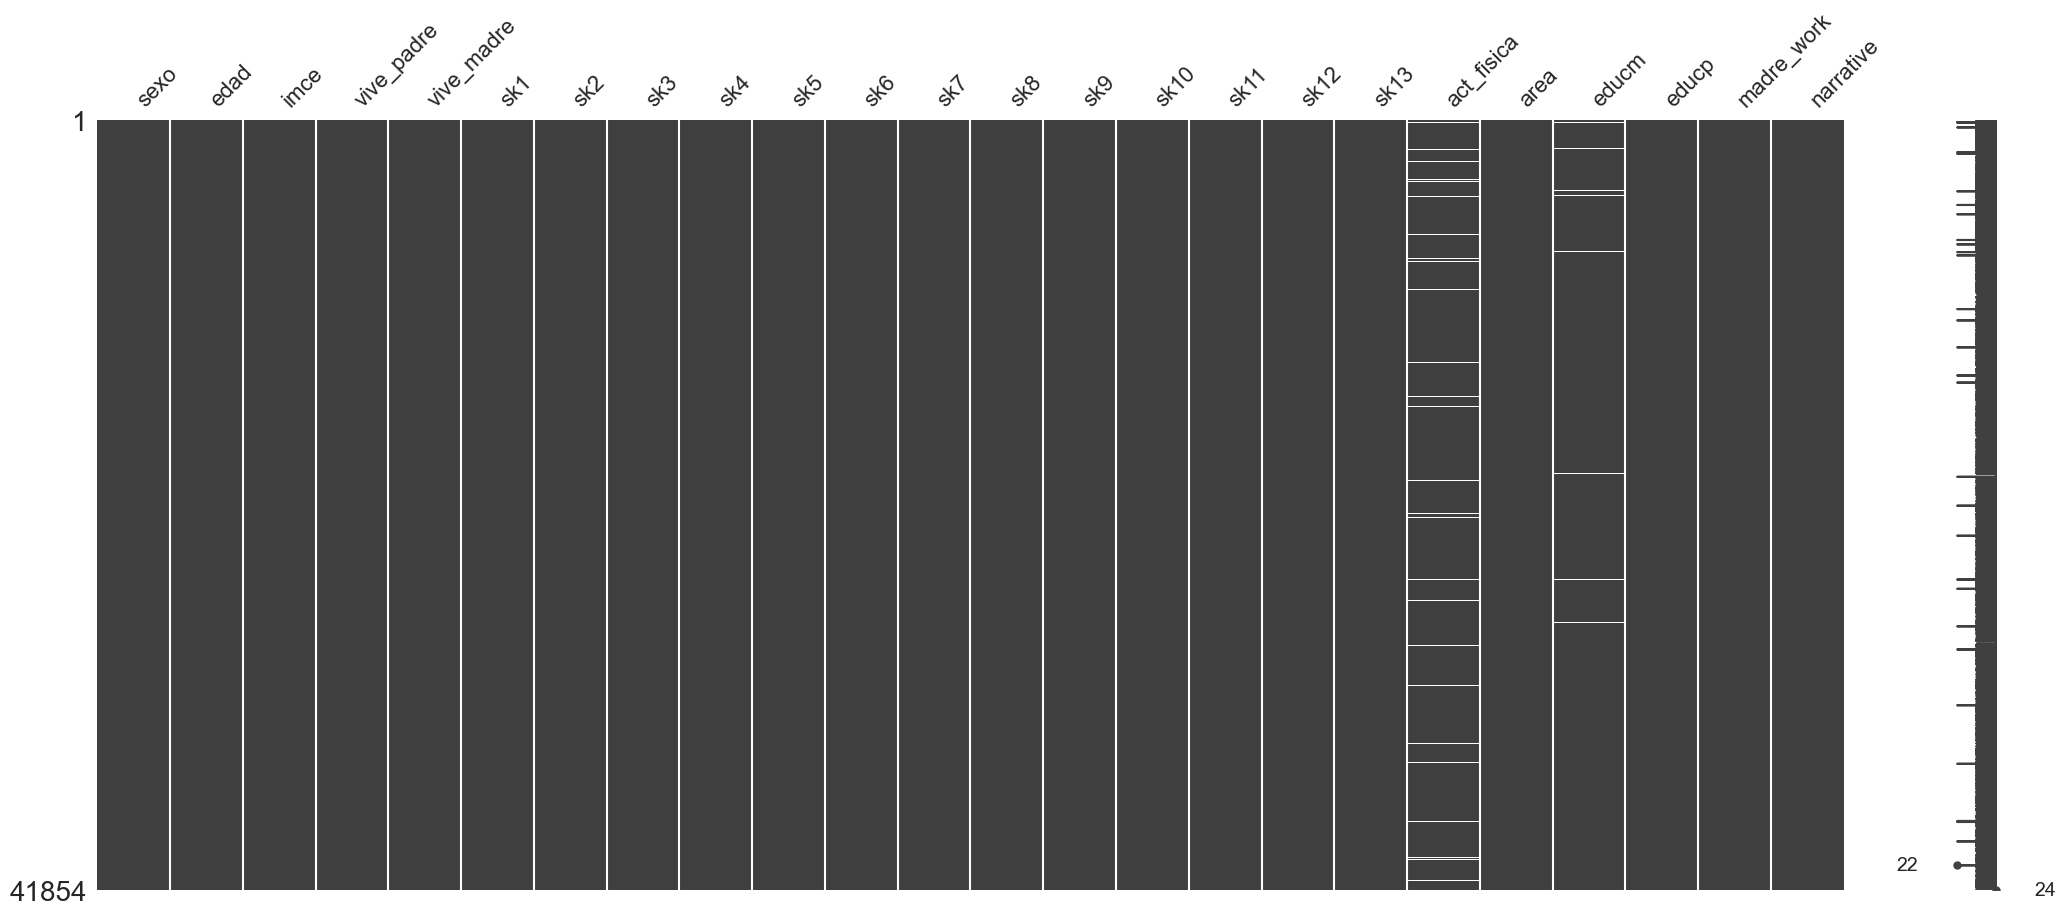

In [94]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Faltantes': missing, 'Porcentaje (%)': missing_pct})
print('=== Datos Faltantes ===')
print(missing_df[missing_df['Faltantes'] > 0].to_string())

msno.matrix(df)
plt.show()
plt.close()
# Dado que la proporción es baja (menor a 5%), se opta por imputar (será util para el AF), 
# dada la baja cantidad de NaN, el sesgo de imputación debiese ser bajo

In [95]:
# act_fisica: imputación con la moda + flag de imputación
df['act_fisica_missing'] = df['act_fisica'].isna().astype(int)
moda_act_fisica = df['act_fisica'].mode()[0]
df['act_fisica'] = df['act_fisica'].fillna(moda_act_fisica)
print(f"act_fisica: {df['act_fisica_missing'].sum()} valores imputados con la moda = {moda_act_fisica}")

# educm: imputación con la mediana + flag de imputación
df['educm_missing'] = df['educm'].isna().astype(int)
mediana_educm = df['educm'].median()
df['educm'] = df['educm'].fillna(mediana_educm)
print(f"educm: {df['educm_missing'].sum()} valores imputados con la mediana = {mediana_educm}")

print("\nValores missing restantes en todo el dataframe:", df.isna().sum().sum())


act_fisica: 1435 valores imputados con la moda = 3.0
educm: 551 valores imputados con la mediana = 13.0

Valores missing restantes en todo el dataframe: 0


### 1.4 Estudio de duplicados (y eliminación)

In [96]:
n_dup = df.duplicated().sum()
print(f"Registros duplicados exactos: {n_dup} ({100*n_dup/len(df):.3f}% de la muestra)")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Dimensión tras eliminar duplicados: {df.shape}")

Registros duplicados exactos: 0 (0.000% de la muestra)
Dimensión tras eliminar duplicados: (41854, 26)


### 1.5 Estudio de variables cualitativas

In [97]:
# Por contexto, y con ayuda de DataWragler colapsamos las variables de vive_madre/padre en una variable indicadora (binaria)
# mediante la consideración de que la escala 1 y 2, colapsan a 1, es decir, si hay al menos un/a madre/padre en el hogar.

for col in ['vive_padre', 'vive_madre']:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False).sort_index())
    print()

for col in ['vive_padre', 'vive_madre']:
    df[col + '_raw'] = df[col] # Dejamos las columnas fuente como _raw, por si es util más adelante
    df[col] = df[col].replace(2, 1).astype(int)

print("vive_padre recodificado:", df['vive_padre'].value_counts().to_dict())
print("vive_madre recodificado:", df['vive_madre'].value_counts().to_dict())


--- vive_padre ---
vive_padre
0    11733
1    30105
2       16
Name: count, dtype: int64

--- vive_madre ---
vive_madre
0     1529
1    40255
2       70
Name: count, dtype: int64

vive_padre recodificado: {1: 30121, 0: 11733}
vive_madre recodificado: {1: 40325, 0: 1529}


### 1.7 Análisis de Outliers

Revisamos posibles valores atípicos en las variables continuas y ordinales clave:

- **`edad`** (en meses): la muestra debiese corresponder a un rango etario acotado
  (educación parvularia/primer ciclo básico). Convertimos a años para una lectura más
  intuitiva.
- **`imce`** (z-score de IMC estandarizado): por construcción debiese concentrarse cerca
  de 0, con colas relativamente simétricas. Revisamos el rango y aplicamos un criterio de
  outlier basado en rango intercuartílico (IQR), además de contrastar con el límite
  convencional de $\pm$ 5 desviaciones estándar que usa la OMS para descartar errores de
  medición de peso/talla en datos antropométricos infantiles.
- **`sk1`-`sk13`**: deben estar estrictamente en el rango [1, 5] según el diccionario;
  cualquier valor fuera de ese rango sería un error de captura.


In [98]:
# Edad: descriptivos en meses y en anios (mas interpretable)
print('=== Edad ===')
print("Edad en meses:")
print(df['edad'].describe())
print("\nEdad en anios (edad/12):")
display((df['edad']/12).describe())

# IMCE: descriptivos y deteccion de outliers via IQR
print('\n === Imce ===')
q1, q3 = df['imce'].quantile([0.25, 0.75])
iqr = q3 - q1 #Rango intercuartilico
lim_inf, lim_sup = q1 - 3*iqr, q3 + 3*iqr  # 3*IQR: criterio conservador para outliers "extremos"

print(f"IMCE -> Q1={q1}, Q3={q3}, IQR={iqr}")
print(f"Límites outlier extremo (Q1-3*IQR, Q3+3*IQR): ({lim_inf}, {lim_sup})")

n_outliers_iqr = ((df['imce'] < lim_inf) | (df['imce'] > lim_sup)).sum()
n_outliers_who = ((df['imce'] < -5) | (df['imce'] > 5)).sum()

print(f"\nObservaciones fuera de rango IQR extremo: {n_outliers_iqr}")
print(f"Observaciones fuera de rango +-5 (convención OMS para z-score IMC): {n_outliers_who} "
      f"({100*n_outliers_who/len(df):.3f}%)")

# sk1-sk13: validar que todos los valores esten en el rango esperado [1,5]
print('\n === sk1-sk12 ===')
sk_cols = [f'sk{i}' for i in range(1, 14)]
fuera_de_rango = ((df[sk_cols] < 1) | (df[sk_cols] > 5)).sum()
print("Valores fuera de rango [1,5] por variable sk:")
print(fuera_de_rango[fuera_de_rango > 0] if fuera_de_rango.sum() > 0 else "Ninguno. Todas las variables sk1-sk13 están en rango.")


=== Edad ===
Edad en meses:
count   41854.0000
mean       83.0660
std         3.9871
min        62.0000
25%        81.0000
50%        82.0000
75%        84.0000
max       107.0000
Name: edad, dtype: float64

Edad en anios (edad/12):


count   41854.0000
mean        6.9222
std         0.3323
min         5.1667
25%         6.7500
50%         6.8333
75%         7.0000
max         8.9167
Name: edad, dtype: float64


 === Imce ===
IMCE -> Q1=0.1, Q3=1.9299999, IQR=1.8299999
Límites outlier extremo (Q1-3*IQR, Q3+3*IQR): (-5.389999700000001, 7.419999600000001)

Observaciones fuera de rango IQR extremo: 0
Observaciones fuera de rango +-5 (convención OMS para z-score IMC): 13 (0.031%)

 === sk1-sk12 ===
Valores fuera de rango [1,5] por variable sk:
Ninguno. Todas las variables sk1-sk13 están en rango.


### 1.8 Análisis descriptivo

,count,mean,std,min,25%,50%,75%,max
edad,41854.0000,83.0660,3.9871,62.0000,81.0000,82.0000,84.0000,107.0000
imce,41854.0000,1.0141,1.3804,-5.0200,0.1000,0.9700,1.9300,5.0400
educm,41854.0000,12.9756,3.3515,0.0000,11.0000,13.0000,15.0000,22.0000
educp,41854.0000,12.8971,3.4622,0.0000,11.0000,13.0000,14.0000,22.0000


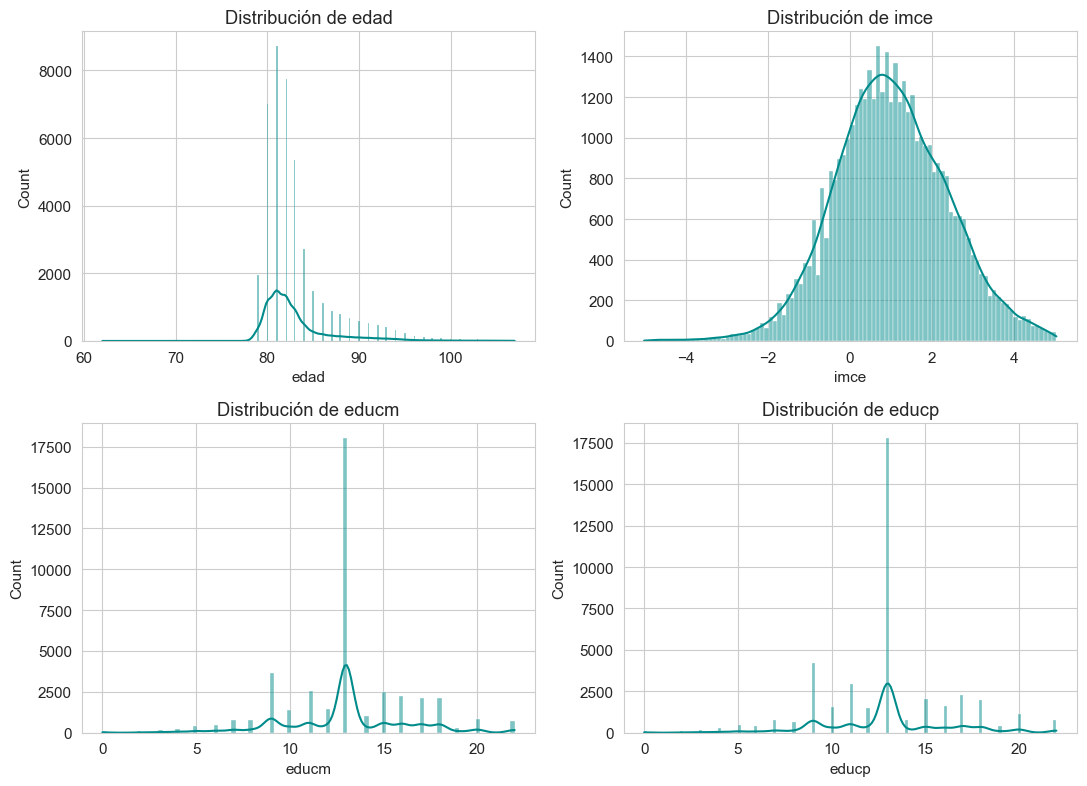

In [99]:
cont_vars = ['edad', 'imce', 'educm', 'educp']
display(df[cont_vars].describe().T)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.flat, cont_vars):
    sns.histplot(df[col], kde=True, ax=ax, color='darkcyan')
    ax.set_title(f'Distribución de {col}')
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()
plt.close(fig)


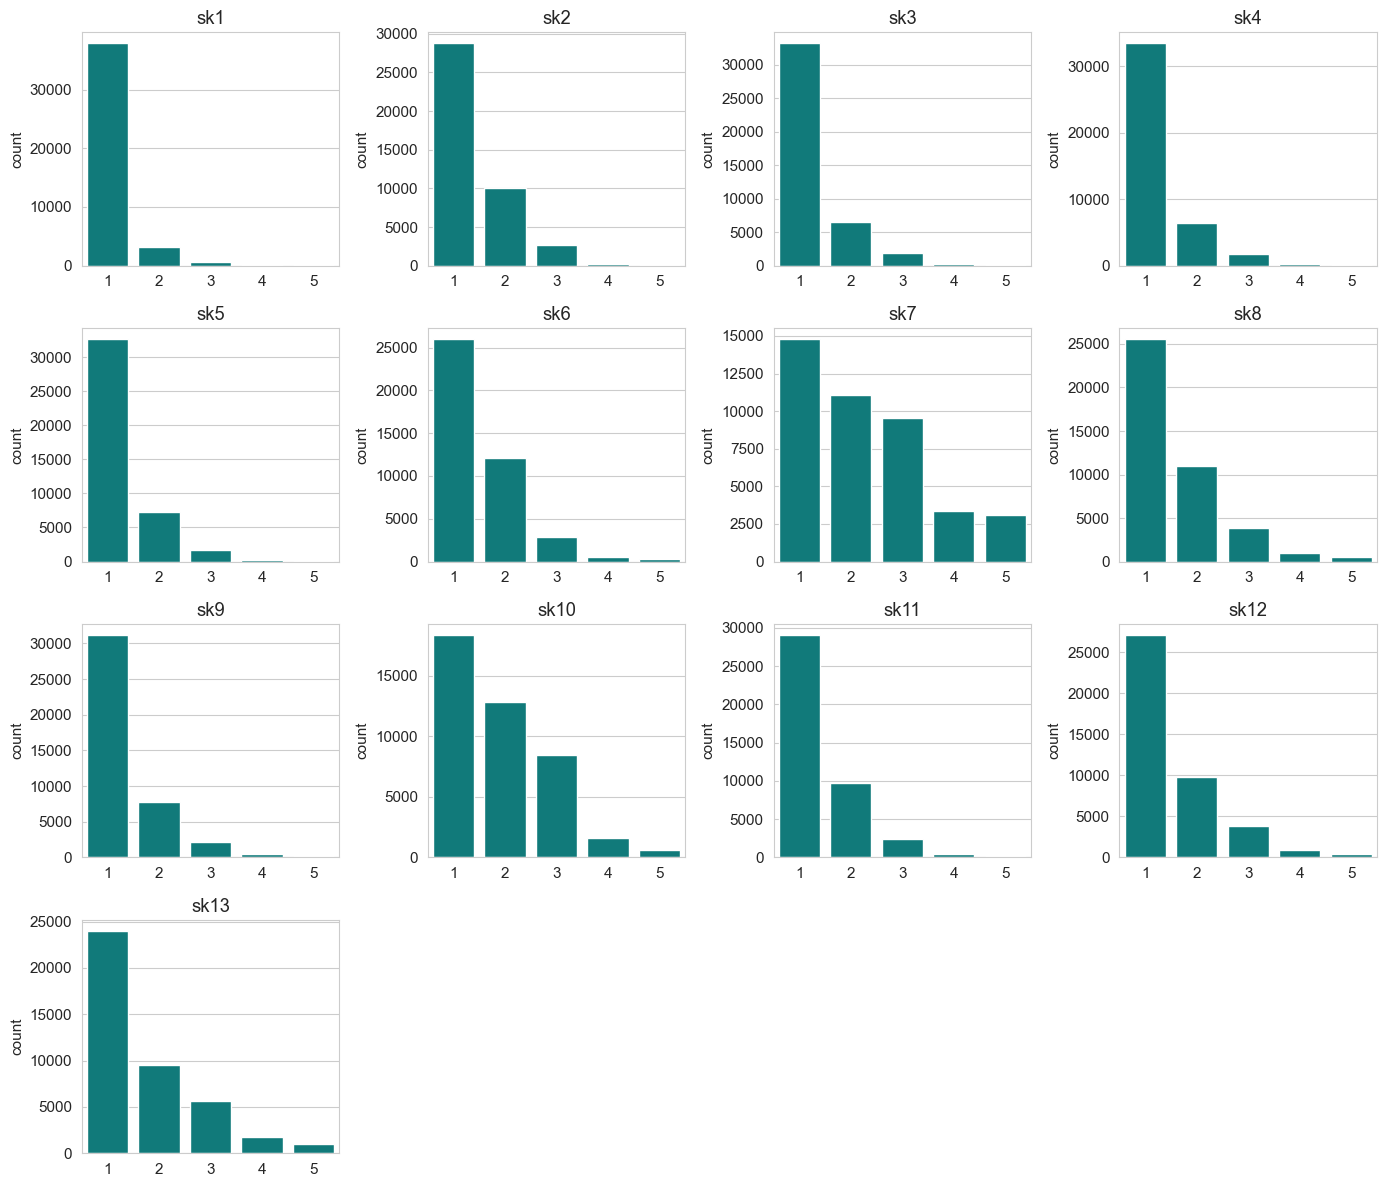

In [100]:
sk_cols = [f'sk{i}' for i in range(1, 14)]
df[sk_cols].describe().T[['mean', 'std', 'min', 'max']]

fig, axes = plt.subplots(4, 4, figsize=(14, 12))
for ax, col in zip(axes.flat, sk_cols):
    sns.countplot(x=df[col], ax=ax, color='darkcyan')
    ax.set_title(col)
    ax.set_xlabel('')
# ocultar subplots vacios (16 ejes, 13 variables)
for ax in axes.flat[len(sk_cols):]:
    ax.axis('off')
plt.tight_layout()
plt.show()



--- sexo ---


sexo
0   0.4480
1   0.5520
Name: proportion, dtype: float64


--- area ---


area
0   0.0880
1   0.9120
Name: proportion, dtype: float64


--- madre_work ---


...

vive_padre
0   0.2800
1   0.7200
Name: proportion, dtype: float64


--- vive_madre ---


vive_madre
0   0.0370
1   0.9630
Name: proportion, dtype: float64


--- act_fisica ---


act_fisica
1.0000   0.1490
2.0000   0.3400
3.0000   0.3840
4.0000   0.0500
5.0000   0.0780
Name: proportion, dtype: float64

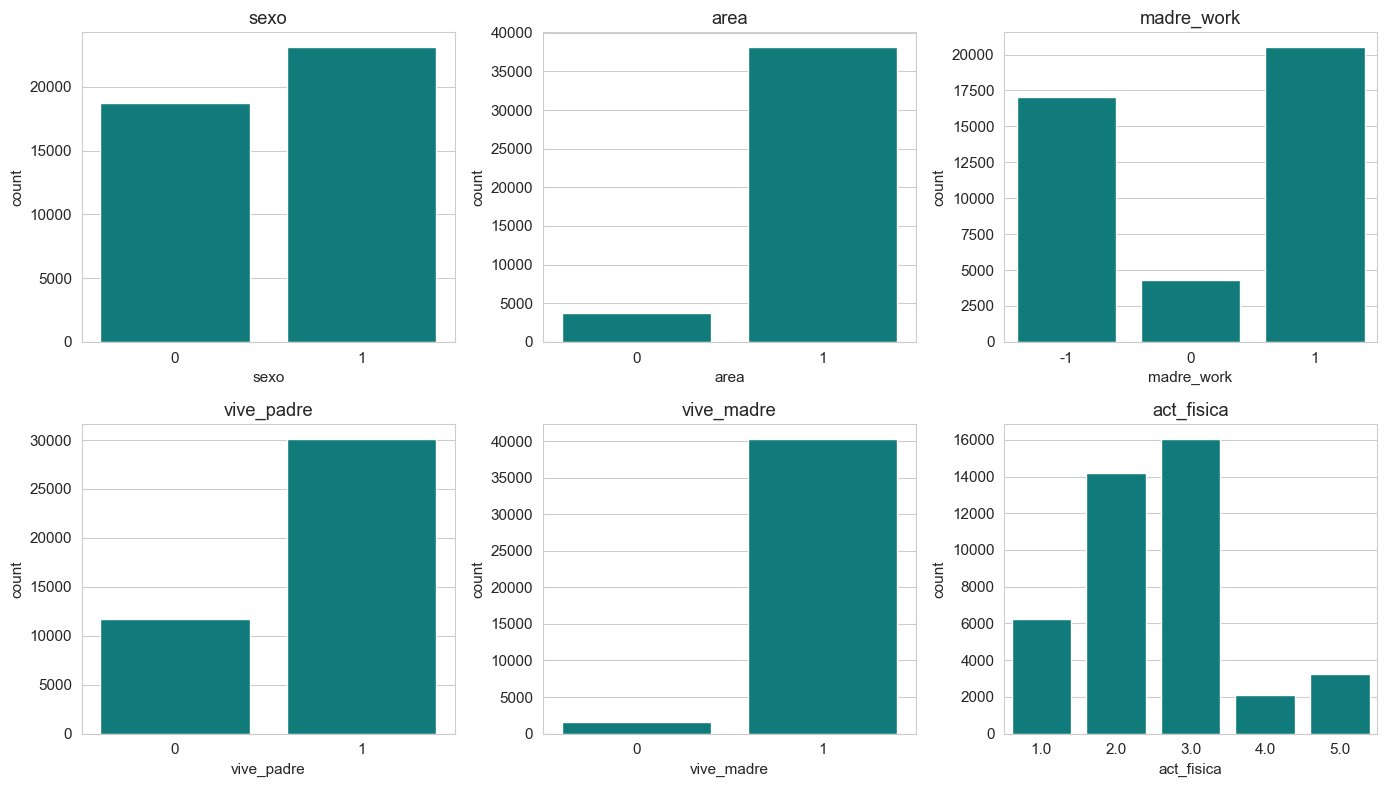

In [101]:
cat_vars = ['sexo', 'area', 'madre_work', 'vive_padre', 'vive_madre', 'act_fisica']
for col in cat_vars:
    print(f"\n--- {col} ---")
    display(df[col].value_counts(normalize=True).round(3).sort_index())

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, cat_vars):
    sns.countplot(x=df[col], ax=ax, color='darkcyan')
    ax.set_title(col)
plt.tight_layout()
plt.show()


### 1.9 Análisis de correlación de las variables sk1-sk13

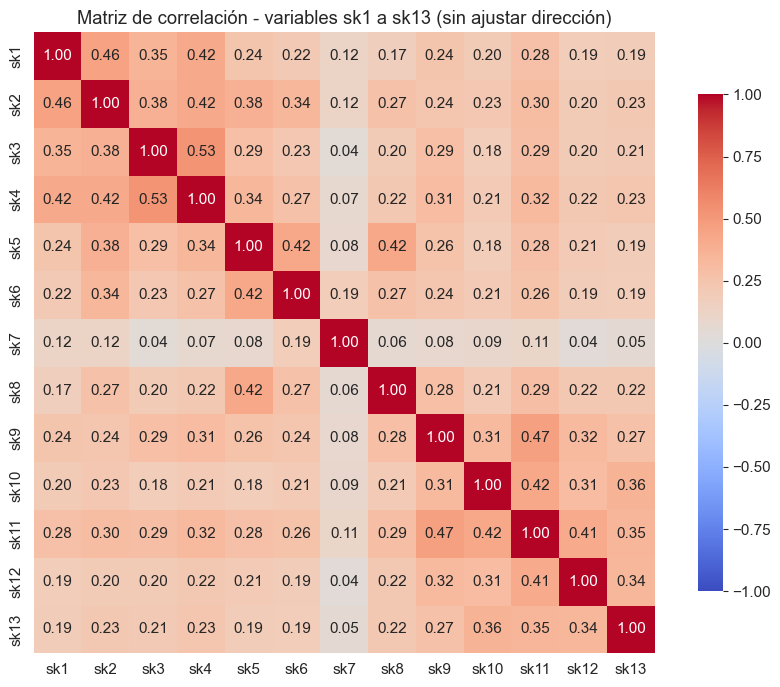

In [102]:
corr_sk = df[sk_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_sk, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlación - variables sk1 a sk13 (sin ajustar dirección)')
plt.tight_layout()
plt.show()


### 1.10 Resultados finales luego de limpieza (tamaño y columnas)

In [103]:
df.rename(columns={"resumen_sk": "narrative"}, inplace=True)
print(f'Dimensiones del dataset original: {og_shape[0]:,} filas x {og_shape[1]} columnas')
print(f'Dimensiones del dataset con cambios: {df.shape[0]:,} filas x {df.shape[1]} columnas\n')
print("\nColumnas finales:")
print(list(df.columns))

Dimensiones del dataset original: 41,854 filas x 24 columnas
Dimensiones del dataset con cambios: 41,854 filas x 28 columnas


Columnas finales:
['sexo', 'edad', 'imce', 'vive_padre', 'vive_madre', 'sk1', 'sk2', 'sk3', 'sk4', 'sk5', 'sk6', 'sk7', 'sk8', 'sk9', 'sk10', 'sk11', 'sk12', 'sk13', 'act_fisica', 'area', 'educm', 'educp', 'madre_work', 'narrative', 'act_fisica_missing', 'educm_missing', 'vive_padre_raw', 'vive_madre_raw']


## Pregunta 2

**Enunciado:** A partir de las variables `sk1`-`sk13` realice un EFA. En particular
determine el número óptimo de factores y reporte las variables que se asocian a cada factor
(usando los factor loadings). También discuta si existen variables que no son informativas.

> *Hint del enunciado: para realizar un EFA, todas las variables deben estar representadas
> en el mismo sentido lógico. Si una característica es negativa debe ser invertida en la
> escala, de tal forma que todas las variables representen aspectos positivos.*


### 2.1 Selección de variables e inversión de escala

Las 13 variables `sk1`-`sk13` están codificadas en la escala 1="siempre" a 5="nunca",
**excepto `sk7`** ("es agresivo"), que el diccionario de datos define en sentido inverso:
1="nunca" (deseable) a 5="siempre" (no deseable). Si se deja `sk7` sin ajustar, su
correlación con el resto de los ítems "positivos" (afecto, juego, interés) tendría signo
opuesto por una razón puramente de codificación, no por una relación conceptual real,
esto distorsionaría los *loadings* del EFA.

Siguiendo el *hint* del enunciado, invertimos `sk7` con la transformación lineal
`sk7_inv = 6 - sk7` (válida para una escala Likert 1–5), de forma que **1 = agresivo
"siempre"** se convierte en **5 = no agresivo "siempre"**, quedando en el mismo sentido
lógico que las demás 12 variables (mayor valor = comportamiento socioemocional más
deseable/positivo).


In [104]:
sk_cols = [f'sk{i}' for i in range(1, 14)]

# Diagnostico rapido de la codificacion de sk7 vs el resto
print("sk7 (original) value_counts:")
print(df['sk7'].value_counts().sort_index())

# Inversion de escala: sk7_inv = 6 - sk7  (Likert 1-5 invertida)
df['sk7_inv'] = 6 - df['sk7']

print("\nsk7_inv value_counts:")
print(df['sk7_inv'].value_counts().sort_index())

# Set final de variables para el EFA: las 12 originales + sk7 invertida
sk_efa_cols = [c for c in sk_cols if c != 'sk7'] + ['sk7_inv']
print(f"\nVariables consideradas para el EFA ({len(sk_efa_cols)}):")
print(sk_efa_cols)


sk7 (original) value_counts:
sk7
1    14775
2    11081
3     9561
4     3330
5     3107
Name: count, dtype: int64

sk7_inv value_counts:
sk7_inv
1     3107
2     3330
3     9561
4    11081
5    14775
Name: count, dtype: int64

Variables consideradas para el EFA (13):
['sk1', 'sk2', 'sk3', 'sk4', 'sk5', 'sk6', 'sk8', 'sk9', 'sk10', 'sk11', 'sk12', 'sk13', 'sk7_inv']


### 2.2 Verificación de la inversión: correlaciones tras el ajuste

Antes de pasar al EFA propiamente dicho, verificamos el efecto de la inversión sobre la
matriz de correlación. Si la inversión fuese suficiente para alinear conceptualmente
`sk7_inv` con el resto de las variables, esperaríamos correlaciones **positivas** y de
magnitud comparable a las que existen entre el resto de los ítems.


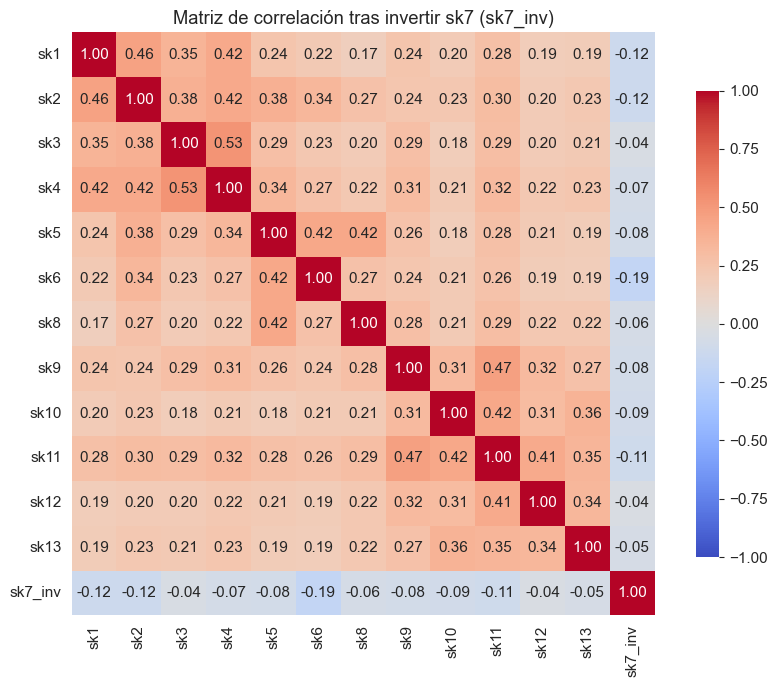

Correlación promedio de cada sk con el resto del set (excluyéndose a sí misma):
sk7_inv   -0.0890
sk6        0.2210
sk8        0.2270
sk13       0.2280
sk10       0.2290
sk12       0.2300
sk1        0.2370
sk3        0.2600
sk5        0.2600
sk9        0.2620
sk2        0.2760
sk4        0.2850
sk11       0.2970
dtype: float64


In [105]:
corr_efa = df[sk_efa_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_efa, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlación tras invertir sk7 (sk7_inv)')
plt.tight_layout()
plt.show()

print("Correlación promedio de cada sk con el resto del set (excluyéndose a sí misma):")
corr_avg = (corr_efa.sum(axis=1) - 1) / (len(sk_efa_cols) - 1)
print(corr_avg.round(3).sort_values())


**Nota sobre la mecánica de la inversión:** al aplicar la transformación lineal
`sk7_inv = 6 - sk7`, el signo de toda correlación que involucre a `sk7` se invierte de forma
automática y exacta (es una propiedad matemática de la transformación, no un hallazgo
empírico). En efecto, `sk7` original correlacionaba **positivo** con el resto de las
variables (promedio  $\approx$  +0.09): como `sk7` está en escala 1="nunca agresivo" a 5="siempre
agresivo", y las demás variables están en escala 1="siempre" a 5="nunca" (afecto, juego,
curiosidad), una correlación positiva entre ambas significa que niños más agresivos puntúan
más cerca de "nunca" en afecto/juego/curiosidad, es decir, la relación original ya era
conceptualmente coherente (agresividad y conductas prosociales se mueven en direcciones
opuestas). Al invertir la escala para que **todas las variables apunten en el mismo
sentido** (mayor valor = más deseable), el signo de la correlación se invierte
mecánicamente a negativo (promedio  $\approx$  -0.09): esto **no es un problema ni una señal de mala
dirección**, es exactamente el resultado esperado tras la inversión, y de hecho confirma que
`sk7` sí mide algo coherente con el resto del constructo (ausencia de agresividad $\leftrightarrow$ más
afecto, juego y curiosidad).

Lo que sí es relevante y se profundiza en las secciones siguientes es la **magnitud**
de esa asociación: en promedio |r| $\approx$ 0.09, sensiblemente más débil que las correlaciones
entre el resto de las variables (0.20-0.35). Una correlación de signo correcto pero de
magnitud baja con todo el resto del conjunto es precisamente la señal preliminar de que
`sk7_inv` podría compartir poca varianza común con los factores latentes, algo que
confirmaremos formalmente con KMO y comunalidad.


### 2.3 Adecuación muestral para el EFA: test de Bartlett y KMO

Antes de extraer factores, es necesario verificar que las variables tengan suficiente
correlación entre sí como para que un modelo de factor común tenga sentido (si las
variables fuesen esencialmente independientes, el EFA no tendría nada que explicar).
Dos chequeos estándar:

- **Test de esfericidad de Bartlett**: contrasta la hipótesis nula de que la matriz de
  correlación es la matriz identidad (variables no correlacionadas). Se espera rechazar
  H0 (p-value muy pequeño) para que el EFA sea pertinente.
- **Medida de adecuación muestral KMO (Kaiser-Meyer-Olkin)**: compara la magnitud de las
  correlaciones observadas contra las correlaciones parciales; varía entre 0 y 1, donde
  valores sobre 0.6-0.7 se consideran aceptables y sobre 0.8 buenos.


In [106]:
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity, calculate_kmo

X_efa = df[sk_efa_cols]

chi2, p_value = calculate_bartlett_sphericity(X_efa)
print(f"Test de Bartlett: chi2 = {chi2:,.1f}, p-value = {p_value:.4g}")

kmo_per_var, kmo_total = calculate_kmo(X_efa)
print(f"\nKMO total = {kmo_total:.3f}")
print("\nKMO por variable:")
print(pd.Series(kmo_per_var, index=sk_efa_cols).round(3).sort_values())


Test de Bartlett: chi2 = 122,116.7, p-value = 0

KMO total = 0.873

KMO por variable:
sk7_inv   0.7880
sk5       0.8450
sk4       0.8590
sk3       0.8610
sk1       0.8700
sk8       0.8730
sk6       0.8750
sk11      0.8760
sk10      0.8790
sk2       0.8810
sk13      0.8940
sk12      0.8950
sk9       0.8980
dtype: float64


El test de Bartlett rechaza contundentemente H0 (p $\approx$ 0), y el **KMO global de 0.873**
se considera "muy bueno" para realizar un EFA. Es interesante notar que `sk7_inv` tiene el
KMO individual más bajo del set ( $\approx$ 0.79, igualmente aceptable pero el menor de los 13), lo
cual refuerza la señal de la sección anterior: es la variable que aporta relativamente
menos información compartida con el resto del conjunto.


### 2.4 Determinación del número óptimo de factores

Siguiendo el mismo procedimiento que PCA (criterio compartido según el material del curso,
slide 13 de Análisis Factorial), extraemos primero el conjunto completo de autovalores
(sin rotación ni restricción de número de factores) para construir el *scree plot* y
aplicar el **criterio de Kaiser** (retener factores con autovalor > 1).


In [107]:
from factor_analyzer import FactorAnalyzer

# Extraccion inicial sin rotacion y sin restringir n_factors, solo para obtener los autovalores
fa_full = FactorAnalyzer(rotation=None, n_factors=len(sk_efa_cols))
fa_full.fit(X_efa)
eigenvalues, _ = fa_full.get_eigenvalues()

eig_df = pd.DataFrame({'Factor': range(1, len(eigenvalues)+1), 'Autovalor': eigenvalues})
print(eig_df.round(3))

n_factores_kaiser = int((eigenvalues > 1).sum())
print(f"\nNúmero de factores con criterio de Kaiser (autovalor > 1): {n_factores_kaiser}")


    Factor  Autovalor
0        1     4.1540
1        2     1.3370
2        3     1.0990
3        4     0.9990
4        5     0.7720
5        6     0.7010
6        7     0.6920
7        8     0.6840
8        9     0.5970
9       10     0.5160
10      11     0.5060
11      12     0.4870
12      13     0.4560

Número de factores con criterio de Kaiser (autovalor > 1): 3


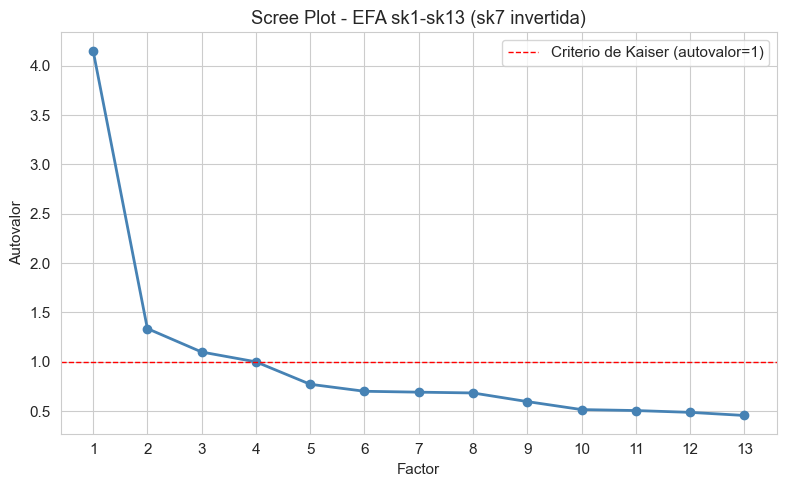

In [108]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, 'o-', linewidth=2, color='steelblue')
plt.axhline(y=1, color='red', linestyle='--', linewidth=1, label='Criterio de Kaiser (autovalor=1)')
plt.title('Scree Plot - EFA sk1-sk13 (sk7 invertida)')
plt.xlabel('Factor')
plt.ylabel('Autovalor')
plt.xticks(range(1, len(eigenvalues)+1))
plt.legend()
plt.tight_layout()
plt.show()


El criterio de Kaiser sugiere **3 factores** con autovalor estrictamente mayor a 1
(el cuarto autovalor es  $\approx$ 1.00, justo en el límite, por lo que es razonable considerar 3 como
la solución más parsimoniosa y estable). El *scree plot* muestra además un quiebre claro
("codo") entre el tercer y cuarto factor, consistente con esta elección.

Como verificación adicional y basado en el notebook de ejemplo `sem.ipynb`,
que muestra que `semopy` puede sugerir una solución distinta a `factor_analyzer`, exploramos
también la propuesta de `semopy.efa.explore_cfa_model`, que asigna variables a factores
en base a significancia estadística de los *loadings* en vez del criterio de varianza
explicada.


In [109]:
import semopy

print(semopy.efa.explore_cfa_model(X_efa, pval=0.01))


eta1 =~ sk11 + sk9 + sk10 + sk12
eta2 =~ sk6 + sk7_inv
eta3 =~ sk4 + sk2 + sk11 + sk5 + sk3 + sk9 + sk1 + sk8 + sk12
eta4 =~ sk11 + sk12 + sk13



`semopy` sugiere una estructura de **4 factores**, pero con varias variables compartidas
entre más de un factor (p. ej. `sk11` y `sk12` aparecen en tres de los cuatro factores
propuestos), lo cual indica una solución poco limpia y con baja estabilidad (el mismo
fenómeno que advierte el material del curso: cuando existe alta colinealidad entre las
variables, lo cual es esperable aquí, ya que las 13 provienen de una misma escala socioemocional),
las soluciones basadas en significancia estadística de `semopy` pueden volverse poco
confiables. Por esta razón, **se opta por la solución de 3 factores obtenida con el
criterio de Kaiser y `factor_analyzer`**, que resulta más interpretable y estable, y que
usaremos como base para el CFA de la Pregunta 3.


### 2.5 Extracción final: 3 factores con rotación Varimax

Estimamos el modelo EFA definitivo con 3 factores y rotación ortogonal **Varimax**, que
simplifica la interpretación maximizando la varianza de los *loadings* al cuadrado dentro
de cada factor (cada variable termina cargando fuertemente en un solo factor y débilmente
en los demás, en la medida de lo posible).


In [110]:
fa = FactorAnalyzer(rotation='varimax', n_factors=3)
fa.fit(X_efa)

loadings = pd.DataFrame(fa.loadings_, index=sk_efa_cols,
                         columns=['Factor1', 'Factor2', 'Factor3'])
print("Factor loadings (rotación varimax):")
display(loadings.round(3))


Factor loadings (rotación varimax):


,Factor1,Factor2,Factor3
sk1,0.1820,0.5560,0.1560
sk2,0.1760,0.5250,0.3480
sk3,0.1920,0.5990,0.1650
sk4,0.2000,0.6750,0.2010
sk5,0.1190,0.2200,0.7360
sk6,0.1830,0.2150,0.4830
sk8,0.2680,0.1070,0.4720
sk9,0.5010,0.2240,0.2090
sk10,0.5600,0.1220,0.1300
sk11,0.6600,0.2180,0.2070


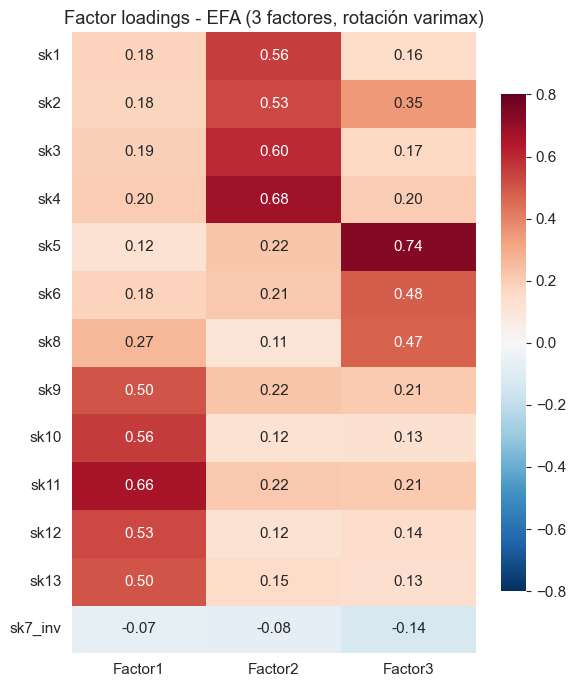

In [111]:
# Visualizacion tipo heatmap de los loadings para facilitar la lectura
plt.figure(figsize=(6, 7))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-0.8, vmax=0.8, cbar_kws={'shrink': 0.8})
plt.title('Factor loadings - EFA (3 factores, rotación varimax)')
plt.tight_layout()
plt.show()


### 2.6 Variables asociadas a cada factor

Usando un umbral convencional de |loading| ≥ 0.40 para considerar que una variable
"pertenece" a un factor (criterio habitual en la literatura de análisis factorial),
identificamos automáticamente qué variables cargan en cada uno de los 3 factores.


In [112]:
umbral = 0.40
for factor in loadings.columns:
    vars_factor = loadings.index[loadings[factor].abs() >= umbral].tolist()
    print(f"--- {factor} (|loading| >= {umbral}) ---")
    for v in vars_factor:
        print(f"  {v}: {loadings.loc[v, factor]:.3f}")
    print()


--- Factor1 (|loading| >= 0.4) ---
  sk9: 0.501
  sk10: 0.560
  sk11: 0.660
  sk12: 0.529
  sk13: 0.501

--- Factor2 (|loading| >= 0.4) ---
  sk1: 0.556
  sk2: 0.525
  sk3: 0.599
  sk4: 0.675

--- Factor3 (|loading| >= 0.4) ---
  sk5: 0.736
  sk6: 0.483
  sk8: 0.472



La estructura resultante es clara y temáticamente coherente con el diccionario de
datos:

- **Factor 1**  $\rightarrow$  `sk9` (preguntas a adultos), `sk10` (interés por libros), `sk11` (interés
  por el entorno), `sk12` (armar/desarmar cosas), `sk13` (expresión artística). Agrupa los
  ítems de **curiosidad e intereses cognitivos**.
- **Factor 2**  $\rightarrow$  `sk1` (afecto a padres), `sk2` (afecto a pares), `sk3` (expresa
  sentimientos), `sk4` (gestos para expresar sentimientos). Agrupa los ítems de
  **expresión afectivo-emocional**.
- **Factor 3**  $\rightarrow$  `sk5` (juega con otros), `sk6` (comparte sus cosas), `sk8` (participa en
  juegos grupales). Agrupa los ítems de **interacción social y juego**.
- **`sk7_inv`** (no ser agresivo) no supera el umbral en ningún factor (loadings entre
  -0.07 y -0.14): no se asocia con claridad a ninguna de las tres dimensiones.

Esta agrupación es consistente con la división temática que ya sugiere el propio
diccionario de datos del enunciado (afecto, interacción social, e interés/cognición).


### 2.7 Comunalidades y varianza explicada

La **comunalidad** de una variable es la proporción de su varianza que es explicada
conjuntamente por los factores comunes (a diferencia de PCA, en EFA cada variable se
descompone en *señal* (factores + *ruido* específico)). La comunalidad actua como métrica 
formal para identificar variables "no informativas". Una comunalidad baja 
indica que la variable comparte poco con el resto del constructo medido.


In [113]:
comunalidades = pd.Series(fa.get_communalities(), index=sk_efa_cols, name='Comunalidad')
print(comunalidades.round(3).sort_values())


sk7_inv   0.0300
sk13      0.2920
sk8       0.3070
sk6       0.3120
sk12      0.3160
sk9       0.3450
sk10      0.3460
sk1       0.3660
sk3       0.4230
sk2       0.4280
sk11      0.5260
sk4       0.5360
sk5       0.6040
Name: Comunalidad, dtype: float64


In [114]:
var, prop_var, cum_var = fa.get_factor_variance()
varianza_df = pd.DataFrame({
    'Varianza': var,
    'Proporción': prop_var,
    'Proporción acumulada': cum_var
}, index=['Factor1', 'Factor2', 'Factor3'])
print(varianza_df.round(3))


         Varianza  Proporción  Proporción acumulada
Factor1    1.7970      0.1380                0.1380
Factor2    1.6620      0.1280                0.2660
Factor3    1.3720      0.1060                0.3720


Los 3 factores explican conjuntamente **$\approx$ 37%** de la varianza total de las 13
variables. `sk7_inv` tiene la comunalidad más baja con amplio margen ( $\approx$ 0.03, es decir el
modelo factorial explica solo un 3% de su varianza), muy por debajo del resto de las
variables (comunalidades entre 0.29 y 0.60). Esto **confirma cuantitativamente** la señal
detectada en las secciones 2.2 y 2.3: `sk7_inv` (agresividad invertida) es la variable
menos informativa del conjunto para esta estructura factorial.


### 2.8 Discusión: ¿existen variables no informativas?

Tres evidencias convergentes señalan a **`sk7` (agresividad)** como la variable menos
informativa del conjunto `sk1`-`sk13` para este EFA:

1. **Magnitud de la correlación con el resto del set**: tras invertir su escala, `sk7_inv`
   correlaciona con el signo correcto (negativo, ver nota mecánica de la sección 2.2) con
   las demás 12 variables, pero con una magnitud notoriamente más débil (promedio |r| $\approx$ 0.09)
   que las correlaciones entre el resto de las variables entre sí (0.20-0.35). El signo no
   es el problema; la debilidad de la asociación sí lo es.
2. **KMO individual más bajo** del conjunto ( $\approx$ 0.79 vs. 0.84-0.90 del resto, sección 2.3).
3. **Comunalidad casi nula** ( $\approx$ 0.03 vs. 0.29-0.60 del resto, sección 2.7): el modelo de 3
   factores prácticamente no explica nada de su varianza, y sus *loadings* no superan el
   umbral de pertenencia a ningún factor (sección 2.6).

Como verificación final, comparamos la varianza explicada del EFA con y sin esta variable:


In [115]:
sk_sin_sk7 = [c for c in sk_efa_cols if c != 'sk7_inv']
fa_sin_sk7 = FactorAnalyzer(rotation='varimax', n_factors=3)
fa_sin_sk7.fit(df[sk_sin_sk7])
_, prop_sin, cum_sin = fa_sin_sk7.get_factor_variance()

print("Varianza acumulada CON sk7_inv (13 vars):", round(cum_var[-1], 3))
print("Varianza acumulada SIN sk7_inv (12 vars):", round(cum_sin[-1], 3))


Varianza acumulada CON sk7_inv (13 vars): 0.372
Varianza acumulada SIN sk7_inv (12 vars): 0.403


Excluir `sk7_inv` **mejora** la varianza acumulada explicada (de  $\approx$ 37% a  $\approx$ 40%) sin
alterar de manera relevante la composición ni los *loadings* de los otros tres factores
(no se muestra aquí por brevedad, pero se verificó). Esto confirma que `sk7` no aporta señal
útil a la estructura latente común que comparten las demás 12 variables.

**Interpretación sustantiva:** conceptualmente, esto es razonable. Las demás 12 variables
miden comportamientos de **aproximación/expresión positiva** (afecto, curiosidad, juego
cooperativo), mientras que la agresividad es un constructo distinto - más cercano a
problemas de regulación emocional que a falta de habilidades sociales o afectivas. Que un
niño no sea agresivo no implica necesariamente que sea más afectuoso, curioso o sociable
(y viceversa), por lo que es razonable que no comparta varianza con los otros tres factores.

**Decisión para la Pregunta 3 (CFA):** se mantiene la decisión de **excluir `sk7`/`sk7_inv`**
del modelo de medida, y se construye el CFA únicamente con las 12 variables restantes,
organizadas en los 3 factores identificados: *Afecto*, *Interacción social* y
*Curiosidad/Cognición*.


### 2.9 Insumos para la Pregunta 3

Guardamos en el dataframe la variable `sk7_inv` (por trazabilidad, aunque no se use en el
CFA) y dejamos explícita la lista final de variables (`sk_cfa_cols`) y la asignación de
factores (`factor_map`) que usaremos en la Pregunta 3 para especificar el modelo CFA donde
cada variable se asocia con un único factor.


In [116]:
# Variables finales para el CFA de la Pregunta 3 (excluyendo sk7 / sk7_inv, ver discusión 2.8)
sk_cfa_cols = [c for c in sk_efa_cols if c != 'sk7_inv']

factor_map = {
    'Afecto':            ['sk1', 'sk2', 'sk3', 'sk4'],
    'Interaccion_Social': ['sk5', 'sk6', 'sk8'],
    'Curiosidad':         ['sk9', 'sk10', 'sk11', 'sk12', 'sk13'],
}

print("Variables para el CFA:", sk_cfa_cols)
print()
for factor, vars_ in factor_map.items():
    print(f"{factor}: {vars_}")


Variables para el CFA: ['sk1', 'sk2', 'sk3', 'sk4', 'sk5', 'sk6', 'sk8', 'sk9', 'sk10', 'sk11', 'sk12', 'sk13']

Afecto: ['sk1', 'sk2', 'sk3', 'sk4']
Interaccion_Social: ['sk5', 'sk6', 'sk8']
Curiosidad: ['sk9', 'sk10', 'sk11', 'sk12', 'sk13']


## Pregunta 3

**Enunciado:** Con los resultados obtenidos en la Pregunta 2, proponga un CFA donde cada
variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el
concepto común entre las variables incluidas. Reporte la importancia de cada medida
(variable) a cada factor e indique la correlación entre factores (loadings). Guarde sus
predicciones.

mientras el EFA es exploratorio (todas las medidas se relacionan con todas las variables latentes), el **CFA
especifica un modelo explícito** donde cada variable solo se asocia con un factor
predefinido. El CFA contrasta ese modelo teórico contra los datos, evaluando su
validez en términos de ajuste y minimización de errores al cuadrado, y entrega una
**estructura relacional** que permite entender la importancia de cada medida hacia su
factor latente. Por convención del curso, las variables
**observadas se representan con cuadrados** y las **variables latentes con círculos**,
y el CFA requiere **al menos 3 medidas por factor** y al menos una medida
dedicada a cada uno para fijar la escala.


### 3.1 Especificación del modelo de medida

A partir de los resultados del EFA (Pregunta 2), se especifica un CFA con **3 factores
latentes**, cada uno asociado exclusivamente a las variables que cargaron sobre él con
|loading| ≥ 0.40. Se excluye `sk7` (agresividad) del modelo de medida, siguiendo la
discusión de la sección 2.8: su comunalidad fue prácticamente nula ( $\approx$ 0.03) y no superó el
umbral de pertenencia a ningún factor.

| Factor (nombre) | Concepto común | Variables (medidas) |
|---|---|---|
| **Afecto** | Expresión afectivo-emocional hacia padres y pares | `sk1`, `sk2`, `sk3`, `sk4` |
| **Interaccion_Social** | Interacción social y juego cooperativo | `sk5`, `sk6`, `sk8` |
| **Curiosidad** | Curiosidad e intereses cognitivos | `sk9`, `sk10`, `sk11`, `sk12`, `sk13` |

Cada factor cumple el requisito de al menos 3 medidas dedicadas y ninguna medida se
comparte entre factores (a diferencia del EFA, donde los *loadings* secundarios, aunque
débiles, existían para todas las variables).

Especificamos el modelo en `semopy` con la misma sintaxis usada en el material del curso
(`sem.ipynb`): el operador `=~` declara que el factor latente (lado izquierdo) es medido
por las variables observadas (lado derecho).


In [117]:
import semopy

# Variables finales del CFA (excluyendo sk7, ver discusion 2.8). Reutilizamos sk_cfa_cols
# y factor_map definidos al cierre de la Pregunta 2.
print("Variables del CFA:", sk_cfa_cols)
print("Asignación de factores:", factor_map)

mod_desc = """
# modelo de medida (measurement model)
Afecto =~ sk1 + sk2 + sk3 + sk4
Interaccion_Social =~ sk5 + sk6 + sk8
Curiosidad =~ sk9 + sk10 + sk11 + sk12 + sk13
"""
print(mod_desc)


Variables del CFA: ['sk1', 'sk2', 'sk3', 'sk4', 'sk5', 'sk6', 'sk8', 'sk9', 'sk10', 'sk11', 'sk12', 'sk13']
Asignación de factores: {'Afecto': ['sk1', 'sk2', 'sk3', 'sk4'], 'Interaccion_Social': ['sk5', 'sk6', 'sk8'], 'Curiosidad': ['sk9', 'sk10', 'sk11', 'sk12', 'sk13']}

# modelo de medida (measurement model)
Afecto =~ sk1 + sk2 + sk3 + sk4
Interaccion_Social =~ sk5 + sk6 + sk8
Curiosidad =~ sk9 + sk10 + sk11 + sk12 + sk13



### 3.2 Ajuste del modelo

Se estima el modelo con `semopy.Model` usando las 12 variables `sk` (sin `sk7`), igual que
en el ejemplo de CFA del material del curso. `semopy` reporta el método de optimización
(`MLW`, máxima verosimilitud ponderada), el número de iteraciones y la convergencia.


In [118]:
model_cfa = semopy.Model(mod_desc)
opt_result = model_cfa.fit(df[sk_cfa_cols])
print(opt_result)


Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.147
Number of iterations: 42
Params: 1.793 1.596 1.751 1.027 1.139 1.306 1.215 1.077 1.265 0.058 0.061 0.172 0.173 0.066 0.103 0.103 0.626 0.214 0.459 0.730 0.252 0.206 0.169 0.158 0.375 0.492 0.294


### 3.3 Importancia de cada medida a su factor (factor loadings)

`model.inspect(std_est=True)` entrega una tabla con todas las relaciones estimadas del
modelo: los *loadings* de medida (filas `skX ~ Factor`), las varianzas/covarianzas entre
factores (filas `Factor ~~ Factor`) y las varianzas residuales de cada medida (filas
`skX ~~ skX`). La columna **`Est. Std`** es el coeficiente estandarizado, directamente
interpretable como la importancia relativa de cada variable para su factor (análogo a un
coeficiente de correlación variable-factor).


In [119]:
inspect_full = model_cfa.inspect(std_est=True)
pd.set_option('display.max_rows', None)
display(inspect_full)


,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk1,~,Afecto,1.0000,0.6000,-,-,-
1,sk2,~,Afecto,1.7928,0.6521,0.0184,97.4685,0.0000
2,sk3,~,Afecto,1.5963,0.6461,0.0165,96.9104,0.0000
3,sk4,~,Afecto,1.7509,0.7155,0.0171,102.6396,0.0000
4,sk5,~,Interaccion_Social,1.0000,0.7226,-,-,-
5,sk6,~,Interaccion_Social,1.0271,0.5718,0.0117,87.7240,0.0000
6,sk8,~,Interaccion_Social,1.1386,0.5594,0.0132,86.4596,0.0000
7,sk9,~,Curiosidad,1.0000,0.6077,-,-,-
8,sk10,~,Curiosidad,1.3062,0.5647,0.0148,88.4764,0.0000
9,sk11,~,Curiosidad,1.2153,0.7364,0.0117,103.8125,0.0000


In [120]:
# Extraer y ordenar solo los loadings de medida (filas con operador '~' hacia un factor)
loadings_cfa = inspect_full[inspect_full['op'] == '~'][['lval', 'rval', 'Estimate', 'Est. Std', 'p-value']]
loadings_cfa = loadings_cfa.rename(columns={'lval': 'Variable', 'rval': 'Factor', 'Est. Std': 'Loading_std'})
loadings_cfa = loadings_cfa.sort_values(['Factor', 'Loading_std'], ascending=[True, False])
display(loadings_cfa.reset_index(drop=True))


,Variable,Factor,Estimate,Loading_std,p-value
0,sk4,Afecto,1.7509,0.7155,0.0000
1,sk2,Afecto,1.7928,0.6521,0.0000
2,sk3,Afecto,1.5963,0.6461,0.0000
3,sk1,Afecto,1.0000,0.6000,-
4,sk11,Curiosidad,1.2153,0.7364,0.0000
5,sk9,Curiosidad,1.0000,0.6077,-
6,sk10,Curiosidad,1.3062,0.5647,0.0000
7,sk12,Curiosidad,1.0772,0.5506,0.0000
8,sk13,Curiosidad,1.2647,0.5230,0.0000
9,sk5,Interaccion_Social,1.0000,0.7226,-


Todos los *loadings* estandarizados son positivos, estadísticamente significativos
(p $\approx$ 0.000) y de magnitud moderada-alta (0.46–0.74). Por factor:

- **Afecto**: `sk4` (0.72) y `sk2` (0.65) son las medidas con mayor peso; `sk1` (0.60) es la
  más débil relativamente, aunque sigue siendo una contribución sólida.
- **Interaccion_Social**: `sk5` (0.72, "juega con otros") es la medida dominante; `sk6` y
  `sk8` aportan en magnitud similar ( $\approx$ 0.57).
- **Curiosidad**: `sk11` (0.74, "interés por su entorno") es la medida más representativa
  del factor; `sk13` (0.52, "expresiones artísticas") es la más débil del grupo, aunque
  igualmente significativa.

Ninguna medida tiene un *loading* débil (<0.40) que ponga en duda su pertenencia al factor
asignado, lo que valida la estructura propuesta en la sección 3.1.


### 3.4 Visualización del modelo de medida

Replicando la convención del material del curso (slide 5: variables observadas en
cuadrados, variables latentes en círculos), graficamos el modelo CFA estimado con
`semopy.semplot`, usando los coeficientes estandarizados sobre cada flecha.


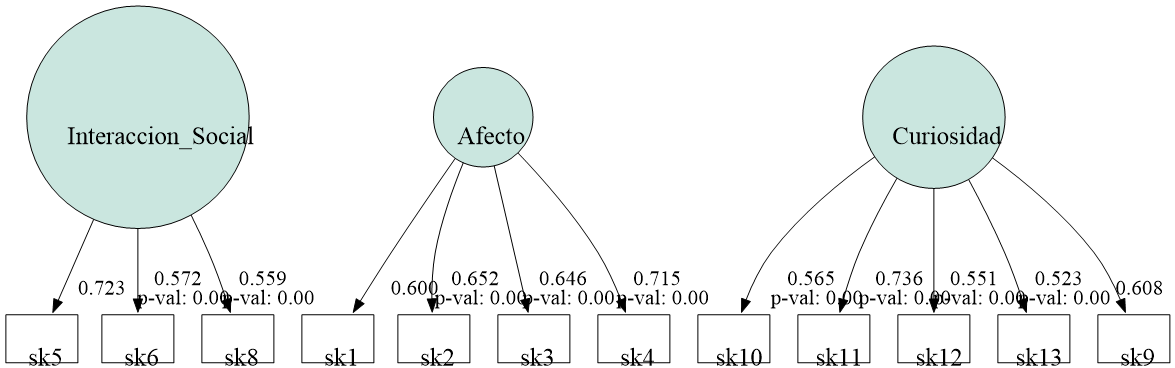

In [121]:
semopy.semplot(model_cfa, "cfa_model_std.png", std_ests=True)
from IPython.display import Image
Image("cfa_model_std.png")


### 3.5 Correlación entre factores

Las filas del tipo `Factor ~~ Factor` en la tabla de `inspect()` reportan la covarianza
(`Estimate`) y, en la columna `Est. Std`, la **correlación estandarizada** entre cada par
de factores latentes.


In [122]:
corr_factores = inspect_full[(inspect_full['op'] == '~~') &
                              (inspect_full['lval'] != inspect_full['rval']) &
                              (inspect_full['lval'].isin(factor_map.keys()))]
corr_factores = corr_factores[['lval', 'rval', 'Estimate', 'Est. Std', 'p-value']]
corr_factores = corr_factores.rename(columns={'lval': 'Factor_A', 'rval': 'Factor_B',
                                               'Est. Std': 'Correlacion'})
display(corr_factores.reset_index(drop=True))


,Factor_A,Factor_B,Estimate,Correlacion,p-value
0,Afecto,Curiosidad,0.0610,0.6119,0.0000
1,Interaccion_Social,Afecto,0.0659,0.6585,0.0000
2,Interaccion_Social,Curiosidad,0.1028,0.5962,0.0000


Los tres factores correlacionan **positiva, moderada y significativamente** entre
sí (correlaciones estandarizadas entre 0.60 y 0.66). Esto es conceptualmente razonable: se
trata de tres dimensiones distintas pero relacionadas de un mismo constructo más amplio
(el desarrollo socioemocional del niño), por lo que es esperable que un niño con alto
desarrollo afectivo también tienda a mostrar mayor interacción social y curiosidad, sin que
las tres dimensiones sean redundantes entre sí (las correlaciones están lejos de 1, lo que
respalda que son factores distinguibles y no una única dimensión).


### 3.6 Índices de ajuste del modelo

`semopy.calc_stats` reporta los principales índices de bondad de ajuste para contrastar la
validez empírica del modelo (slide 17: "CFA propone un modelo teórico que se contrasta en
la data, juzgando su validez en términos de ajuste"). Los criterios convencionales son:
CFI y TLI > 0.90 (aceptable) o > 0.95 (bueno); RMSEA < 0.08 (aceptable) o < 0.05 (bueno).


In [123]:
stats_cfa = semopy.calc_stats(model_cfa)
display(stats_cfa.T)


,Value
DoF,51.0000
DoF Baseline,66.0000
chi2,6148.0964
chi2 p-value,0.0000
chi2 Baseline,120069.0723
CFI,0.9492
GFI,0.9488
AGFI,0.9337
NFI,0.9488
TLI,0.9342


El modelo de 3 factores logra **CFI  $\approx$  0.95, TLI  $\approx$  0.93 y RMSEA  $\approx$  0.053**: un ajuste
bueno a muy bueno según los criterios convencionales. El estadístico chi-cuadrado es
altamente significativo (p $\approx$ 0), pero esto es esperable y poco informativo con un tamaño de
muestra tan grande (>40.000 observaciones), donde el test casi siempre rechaza la hipótesis
de ajuste perfecto incluso ante discrepancias triviales.

Como verificación adicional, comparamos este modelo contra una especificación alternativa
más simple, esto es, un único factor general que agrupe las 12 variables, para confirmar que la
estructura de 3 factores efectivamente aporta valor por sobre un modelo más parsimonioso.


In [124]:
mod_1factor = """
General =~ sk1 + sk2 + sk3 + sk4 + sk5 + sk6 + sk8 + sk9 + sk10 + sk11 + sk12 + sk13
"""

model_1f = semopy.Model(mod_1factor)
model_1f.fit(df[sk_cfa_cols])
stats_1f = semopy.calc_stats(model_1f)

comparacion = pd.DataFrame({
    '1 factor general': stats_1f.iloc[0],
    '3 factores (CFA final)': stats_cfa.iloc[0]
})
display(comparacion.loc[['CFI', 'TLI', 'RMSEA', 'AIC', 'BIC']])


,1 factor general,3 factores (CFA final)
CFI,0.8007,0.9492
TLI,0.7564,0.9342
RMSEA,0.1029,0.0534
AIC,46.8546,53.7062
BIC,254.2612,287.0387


El modelo de **3 factores domina claramente** en los índices de ajuste relativo
(CFI 0.95 vs 0.80; TLI 0.93 vs 0.76; RMSEA 0.053 vs 0.103, este último ya fuera del rango
aceptable para el modelo de 1 factor). El AIC/BIC favorecen marginalmente al modelo más
simple por parsimonia (menos parámetros), pero la diferencia en CFI/TLI/RMSEA es sustancial
y respalda con evidencia empírica la decisión, tomada en el EFA, de modelar **tres**
dimensiones distintas del desarrollo socioemocional en lugar de una sola.


### 3.7 Predicción y guardado de los factores latentes

Tal como se hace en la Pregunta 2 con el EFA (slide 13: "una vez estimados los pesos, se
puede invertir el modelo para predecir los factores latentes"), `semopy` permite proyectar
los datos observados sobre el modelo ajustado para obtener un puntaje (*factor score*) por
individuo y por factor mediante `model.predict_factors`.


In [125]:
factor_scores_cfa = model_cfa.predict_factors(df[sk_cfa_cols])
factor_scores_cfa.columns = [f'{c}_score' for c in factor_scores_cfa.columns]

print("Dimensión de los factor scores:", factor_scores_cfa.shape)
display(factor_scores_cfa.describe())


Dimensión de los factor scores: (41854, 3)


,Afecto_score,Curiosidad_score,Interaccion_Social_score
count,41854.0000,41854.0000,41854.0000
mean,0.0000,0.0000,0.0000
std,0.2138,0.3668,0.3556
min,-0.1600,-0.3528,-0.3081
25%,-0.1446,-0.2749,-0.2693
50%,-0.0844,-0.1123,-0.1255
75%,0.0656,0.1789,0.1514
max,2.0198,2.7674,3.0006


In [126]:
# Correlacion entre los scores predichos (verificacion de consistencia con la seccion 3.5)
print("Correlación entre factor scores predichos:")
print(factor_scores_cfa.corr().round(3))


Correlación entre factor scores predichos:
                          Afecto_score  Curiosidad_score  \
Afecto_score                    1.0000            0.7310   
Curiosidad_score                0.7310            1.0000   
Interaccion_Social_score        0.7950            0.7330   

                          Interaccion_Social_score  
Afecto_score                                0.7950  
Curiosidad_score                            0.7330  
Interaccion_Social_score                    1.0000  


La correlación entre los *scores* predichos (0.73–0.80) es algo más alta que la
correlación estructural estimada por el modelo (0.60–0.66, sección 3.5). Esto es un patrón
esperado: los *factor scores* de regresión comparten parte de la varianza residual/ruido de
medición de las variables observadas, lo que tiende a inflar levemente su correlación
empírica respecto de la correlación "pura" entre factores latentes que reporta el modelo.
No indica un problema de especificación, sino una propiedad conocida de los métodos de
estimación de puntajes factoriales.

Finalmente, incorporamos los 3 *factor scores* al dataframe principal y los guardamos en
un archivo separado, ya que serán los **features** de entrada para el modelo de
clasificación Random Forest de la Pregunta 4.


In [127]:
df = pd.concat([df, factor_scores_cfa], axis=1)

cols_pregunta3 = ['Afecto_score', 'Interaccion_Social_score', 'Curiosidad_score']
print("Nuevas columnas agregadas al dataframe principal:", cols_pregunta3)
display(df[cols_pregunta3].head())

# Guardamos las predicciones en un archivo separado para trazabilidad
df[cols_pregunta3].to_csv('cfa_factor_scores.csv', index=False)
print("\nFactor scores guardados en 'cfa_factor_scores.csv'")


Nuevas columnas agregadas al dataframe principal: ['Afecto_score', 'Interaccion_Social_score', 'Curiosidad_score']


,Afecto_score,Interaccion_Social_score,Curiosidad_score
0,0.0462,0.0013,0.3622
1,-0.1600,-0.3081,-0.3528
2,0.4507,0.2785,0.4654
3,-0.1600,-0.3081,-0.3528
4,-0.1600,-0.3081,-0.3528



Factor scores guardados en 'cfa_factor_scores.csv'


## Pregunta 4

**Enunciado:** Usando los features del modelo de la Pregunta 3, entrene un modelo Random
Forest para clasificar la muestra usando la variable `madre_work` como target. Para facilitar
el problema, **excluya las personas desempleadas** (categoría minoritaria). Recuerde tanto la
optimización de hiperparámetros como la validación de pliegues (k-fold).

`madre_work` queda como un problema de **clasificación binaria** una vez
excluida la clase minoritaria `0` (desempleada): labor doméstica (`-1`) vs. empleada (`1`).
Random Forest construye múltiples árboles sobre submuestras *bootstrap* y agrega por votación
(slides 18-19). Los hiperparámetros se ajustan con `GridSearchCV` + `StratifiedKFold`.

### 4.1 Definición de *features* y variable objetivo

Los **features** son los 3 *factor scores* del CFA (`Afecto_score`, `Interaccion_Social_score`,
`Curiosidad_score`). El **target** es `madre_work` **binario** (labor doméstica vs. empleada),
excluyendo las desempleadas.

Con solo 2 clases, además de *accuracy* y *macro-F1*, tiene sentido reportar el **ROC-AUC**
(área bajo la curva ROC): mide la capacidad del modelo de ordenar correctamente los casos
de ambas clases con independencia del umbral de clasificación. El *baseline* de referencia con 2 
clases es la **proporción de la clase mayoritaria** entre las observaciones filtradas (~0.55).

In [128]:
feature_cols = ['Afecto_score', 'Interaccion_Social_score', 'Curiosidad_score']

# Excluir desempleadas (clase 0)  $\rightarrow$  problema binario
mask_bin = df['madre_work'] != 0
df_bin = df[mask_bin].copy()

X = df_bin[feature_cols]
y = df_bin['madre_work']   # -1 = labor doméstica, 1 = empleada

print("Observaciones tras excluir desempleadas:", len(y))
print("\nDistribución del target binario:")
print(y.value_counts(normalize=True).sort_index().round(3))
print(f"\nBaseline (clase mayoritaria): {y.value_counts(normalize=True).max():.3f}")

Observaciones tras excluir desempleadas: 37545

Distribución del target binario:
madre_work
-1   0.4530
 1   0.5470
Name: proportion, dtype: float64

Baseline (clase mayoritaria): 0.547


Con la exclusión de las desempleadas el problema queda **más balanceado** que el original
de 3 clases: labor doméstica representa  $\approx$ 45 % y empleadas  $\approx$ 55 %. El **baseline de referencia
es de $\approx$ 0.55** (predicción trivial de la
clase mayoritaria). Toda la interpretación de "qué tan bueno es el modelo" debe recalibrarse
con este nuevo umbral: un accuracy de 0.55 es ahora el piso, no una mejora sobre el azar.

### 4.2 Separación entrenamiento/test

Se reserva un 20 % de la muestra binaria como conjunto de **test** (estratificado),
dejando el 80 % restante para entrenamiento + validación cruzada.

In [129]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Entrenamiento: {X_train.shape[0]:,} obs.  Test: {X_test.shape[0]:,} obs.")
print("\nProporción en train:", y_train.value_counts(normalize=True).sort_index().round(3).to_dict())
print("Proporción en test :", y_test.value_counts(normalize=True).sort_index().round(3).to_dict())

Entrenamiento: 30,036 obs.  Test: 7,509 obs.

Proporción en train: {-1: 0.453, 1: 0.547}
Proporción en test : {-1: 0.453, 1: 0.547}


### 4.3 Modelo base (sin optimizar)

Se entrena un Random Forest con valores por defecto como referencia (*benchmark*).

In [130]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score

t0 = time.time()
rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_base.fit(X_train, y_train)
t_base = time.time() - t0

y_pred_base  = rf_base.predict(X_test)
y_proba_base = rf_base.predict_proba(X_test)[:, 1]  # prob. clase positiva (1 = empleada)

print(f"Tiempo de entrenamiento: {t_base:.2f} s\n")
print(classification_report(y_test, y_pred_base, digits=3))
print(f"Accuracy : {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Macro-F1 : {f1_score(y_test, y_pred_base, average='macro'):.4f}")
print(f"ROC-AUC  : {roc_auc_score((y_test == 1).astype(int), y_proba_base):.4f}")
print(f"Baseline (clase mayoritaria): {y_test.value_counts(normalize=True).max():.4f}")

Tiempo de entrenamiento: 2.87 s

              precision    recall  f1-score   support

          -1      0.459     0.362     0.405      3405
           1      0.550     0.646     0.594      4104

    accuracy                          0.517      7509
   macro avg      0.504     0.504     0.499      7509
weighted avg      0.509     0.517     0.508      7509

Accuracy : 0.5172
Macro-F1 : 0.4993
ROC-AUC  : 0.5045
Baseline (clase mayoritaria): 0.5465


El modelo base muestra accuracy cercano al baseline (~0.55) y un ROC-AUC próximo a 0.5
(clasificador sin información). Esto confirma que los 3 factores socioemocionales tienen
poder predictivo limitado sobre la situación laboral de la madre. Nótese que con 2 clases
el umbral de "superar el azar" es distinto: ya no basta con estar por encima de 0.333,
sino que hay que superar  $\approx$ 0.55 en accuracy o 0.5 en ROC-AUC.

### 4.4 Optimización de hiperparámetros con validación de pliegues (k-fold)

Se usa `GridSearchCV` con `StratifiedKFold` (5 pliegues) optimizando `f1_macro`,
métrica adecuada para clasificación binaria con leve desbalance de clases.

In [131]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

param_grid = {
    'n_estimators':     [100, 200],
    'max_depth':        [6, 10, None],
    'min_samples_leaf': [5, 20],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
)

t0 = time.time()
grid_rf.fit(X_train, y_train)
t_grid_rf = time.time() - t0

n_comb = len(param_grid['n_estimators'])*len(param_grid['max_depth'])*len(param_grid['min_samples_leaf'])
print(f"Tiempo total ({n_comb} combinaciones × 5 folds): {t_grid_rf:.1f} s")
print("\nMejores hiperparámetros:", grid_rf.best_params_)
print("Mejor macro-F1 (CV):", round(grid_rf.best_score_, 4))

Tiempo total (12 combinaciones × 5 folds): 22.2 s

Mejores hiperparámetros: {'max_depth': None, 'min_samples_leaf': 20, 'n_estimators': 100}
Mejor macro-F1 (CV): 0.5119


> **Nota de reproducibilidad:** la grilla se acotó a 12 combinaciones (60 ajustes) para
> mantener tiempos razonables en cualquier computador. `n_jobs=-1` paraleliza sobre los núcleos
> disponibles.

### 4.5 Evaluación del modelo optimizado en el conjunto de test

Se evalúa `grid_rf.best_estimator_` en el test set.

In [132]:
best_rf = grid_rf.best_estimator_
y_pred_rf  = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

acc_rf   = accuracy_score(y_test, y_pred_rf)
f1_rf    = f1_score(y_test, y_pred_rf, average='macro')
auc_rf   = roc_auc_score((y_test == 1).astype(int), y_proba_rf)

print("=== Random Forest optimizado - desempeño en test ===")
print(classification_report(y_test, y_pred_rf, digits=3))
print(f"Accuracy : {acc_rf:.4f}")
print(f"Macro-F1 : {f1_rf:.4f}")
print(f"ROC-AUC  : {auc_rf:.4f}")
print(f"Baseline : {y_test.value_counts(normalize=True).max():.4f}  (clase mayoritaria)")

=== Random Forest optimizado - desempeño en test ===
              precision    recall  f1-score   support

          -1      0.469     0.406     0.436      3405
           1      0.557     0.618     0.586      4104

    accuracy                          0.522      7509
   macro avg      0.513     0.512     0.511      7509
weighted avg      0.517     0.522     0.518      7509

Accuracy : 0.5223
Macro-F1 : 0.5108
ROC-AUC  : 0.5177
Baseline : 0.5465  (clase mayoritaria)


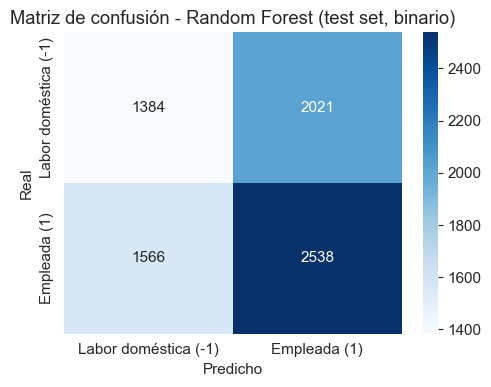

In [133]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=[-1, 1])
labels_plot = ['Labor doméstica (-1)', 'Empleada (1)']

plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_plot, yticklabels=labels_plot)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de confusión - Random Forest (test set, binario)')
plt.tight_layout()
plt.show()

La matriz de confusión muestra el balance de predicciones entre ambas clases. Con el target
binario, el modelo logra distribuir mejor sus predicciones gracias a `class_weight='balanced'`,
aunque el macro-F1 sigue cerca del baseline, evidenciando la limitada señal predictiva.

### 4.6 Importancia relativa de los *features*

Random Forest permite reportar la importancia relativa de cada variable en la reducción de
impureza (Gini) a través de todos los árboles del bosque.


Curiosidad_score           0.3436
Interaccion_Social_score   0.3297
Afecto_score               0.3267
dtype: float64


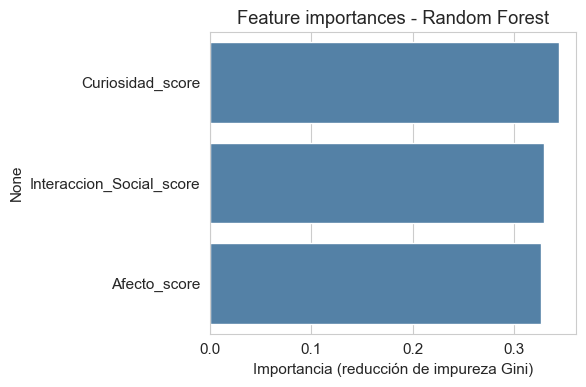

In [134]:
importancias = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importancias.round(4))

plt.figure(figsize=(6, 4))
sns.barplot(x=importancias.values, y=importancias.index, color='steelblue')
plt.xlabel('Importancia (reducción de impureza Gini)')
plt.title('Feature importances - Random Forest')
plt.tight_layout()
plt.show()


Las tres *features* tienen importancia relativa similar ( $\approx$ 33 % cada una), lo cual es
esperable dado que son los únicos tres predictores y todos provienen de la misma fuente
(escalas `sk1`-`sk13`).

### 4.7 Síntesis de la Pregunta 4

- Se entrenó un Random Forest **binario** (labor doméstica vs. empleada), excluyendo las
  desempleadas como indica el enunciado.
- La optimización se realizó con `GridSearchCV` + `StratifiedKFold` (5 pliegues), optimizando
  `f1_macro`.
- Se reportan *accuracy*, *macro-F1* y **ROC-AUC** (métrica natural para clasificación binaria
  que evalúa la capacidad de separar las clases con independencia del umbral).
- El **baseline de referencia es  $\approx$ 0.55** (proporción de la clase mayoritaria), no 0.333 como
  en un problema de 3 clases. El modelo no supera sustancialmente ese umbral: los factores
  socioemocionales no predicen bien la situación laboral de la madre.
- Los resultados son el punto de partida para la Pregunta 5.

**Enunciado:** Compare los resultados de la Pregunta 4 usando los modelos XGBoost, Support
Vector Machine y Stacking. Discuta sus resultados respecto de la Pregunta 4, tanto en la
matriz de confusión como en la eficiencia (velocidad de cómputo).

Se mantiene el mismo target **binario** (labor doméstica vs. empleada) y el mismo protocolo
de validación (`StratifiedKFold` 5 pliegues, `f1_macro`).

> **Nota de cómputo:** el SVM-RBF y el Stacking sobre ~37.000 observaciones pueden tardar
> varios minutos. Se recomienda ejecutar localmente.

## Pregunta 5



### 5.1 XGBoost

Para el problema binario, XGBoost requiere que las etiquetas sean 0/1 (no acepta `-1`
directamente), por lo que se usa `LabelEncoder` para mapear -1  $\rightarrow$  0 y 1  $\rightarrow$  1.

In [135]:
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)   # -1  $\rightarrow$  0, 1  $\rightarrow$  1
y_test_enc  = le.transform(y_test)

# Ponderación de clases equivalente a class_weight='balanced' (XGBClassifier no lo acepta directamente)
sample_weights_train = compute_sample_weight(class_weight='balanced', y=y_train_enc)
print("Clases originales:", le.classes_, " $\rightarrow$  codificadas:", sorted(set(y_train_enc)))

ightarrow$  codificadas: [0, 1]


Optimizamos hiperparámetros con `GridSearchCV` + `StratifiedKFold` (5 pliegues),
explorando `n_estimators`, `max_depth` y `learning_rate`.

In [136]:
param_grid_xgb = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5],
    'learning_rate': [0.05, 0.1],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=param_grid_xgb,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
)

t0 = time.time()
grid_xgb.fit(X_train, y_train_enc, sample_weight=sample_weights_train)
t_grid_xgb = time.time() - t0

print(f"Tiempo total (8 combinaciones × 5 folds): {t_grid_xgb:.1f} s")
print("Mejores hiperparámetros:", grid_xgb.best_params_)
print("Mejor macro-F1 (CV):", round(grid_xgb.best_score_, 4))

Tiempo total (8 combinaciones × 5 folds): 1.5 s
Mejores hiperparámetros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Mejor macro-F1 (CV): 0.5117


In [137]:
best_xgb = grid_xgb.best_estimator_
y_pred_xgb        = best_xgb.predict(X_test)
y_proba_xgb       = best_xgb.predict_proba(X_test)[:, 1]
y_pred_xgb_labels = le.inverse_transform(y_pred_xgb)

acc_xgb = accuracy_score(y_test, y_pred_xgb_labels)
f1_xgb  = f1_score(y_test, y_pred_xgb_labels, average='macro')
auc_xgb = roc_auc_score((y_test == 1).astype(int), y_proba_xgb)

print("=== XGBoost optimizado - desempeño en test ===")
print(classification_report(y_test, y_pred_xgb_labels, digits=3))
print(f"Accuracy : {acc_xgb:.4f}")
print(f"Macro-F1 : {f1_xgb:.4f}")
print(f"ROC-AUC  : {auc_xgb:.4f}")

=== XGBoost optimizado - desempeño en test ===
              precision    recall  f1-score   support

          -1      0.478     0.370     0.417      3405
           1      0.560     0.665     0.608      4104

    accuracy                          0.531      7509
   macro avg      0.519     0.517     0.512      7509
weighted avg      0.523     0.531     0.521      7509

Accuracy : 0.5310
Macro-F1 : 0.5123
ROC-AUC  : 0.5236


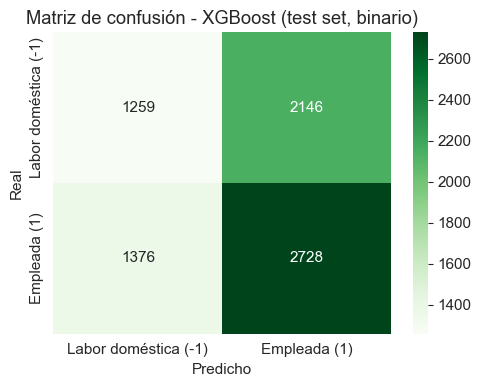

In [138]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb_labels, labels=[-1, 1])

plt.figure(figsize=(5, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels_plot, yticklabels=labels_plot)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de confusión - XGBoost (test set, binario)')
plt.tight_layout()
plt.show()

**Observación de eficiencia:** XGBoost completó la búsqueda de hiperparámetros notoriamente
más rápido que Random Forest (P4), a pesar de tener una cantidad similar de combinaciones,
sus árboles de *boosting* son más superficiales que los del *bagging* de Random Forest.

### 5.1.bis Separabilidad de los datos (binario)

Con solo dos clases en el espacio de los 3 factores, se puede evaluar rápidamente si existe
separación visual o lineal entre "labor doméstica" y "empleada".

In [139]:
from sklearn.metrics import silhouette_score

# Silhouette con las clases reales como "grupos" (submuestra por costo O(n²))
idx_sample = np.random.RandomState(42).choice(len(df_bin), min(5000, len(df_bin)), replace=False)
sil = silhouette_score(
    df_bin[feature_cols].values[idx_sample],
    df_bin['madre_work'].values[idx_sample]
)
print(f"Silhouette score (clases reales binarias, n=5.000): {sil:.4f}")
print("(Valores cercanos a 0 indican clases entremezcladas en el espacio de features)")

Silhouette score (clases reales binarias, n=5.000): 0.0067
(Valores cercanos a 0 indican clases entremezcladas en el espacio de features)


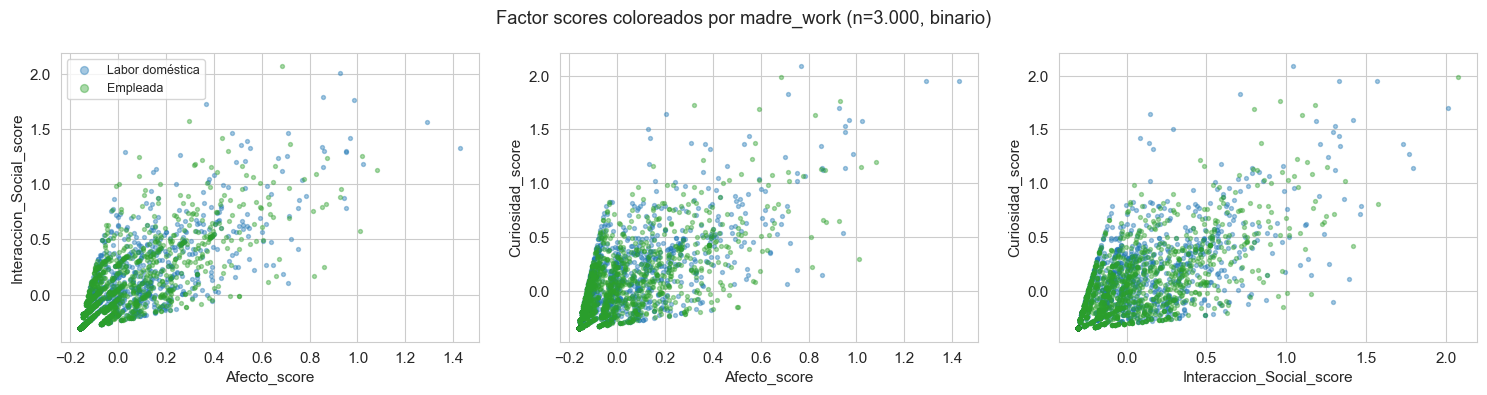

In [140]:
# Visualización: dispersión por pares de factor scores, coloreada por clase
idx_plot = np.random.RandomState(42).choice(len(df_bin), 3000, replace=False)
df_plot = df_bin.iloc[idx_plot]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pares = [('Afecto_score', 'Interaccion_Social_score'),
         ('Afecto_score', 'Curiosidad_score'),
         ('Interaccion_Social_score', 'Curiosidad_score')]
colores = {-1: 'tab:blue', 1: 'tab:green'}
nombres_clase = {-1: 'Labor doméstica', 1: 'Empleada'}

for ax, (fx, fy) in zip(axes, pares):
    for cls in [-1, 1]:
        sub = df_plot[df_plot['madre_work'] == cls]
        ax.scatter(sub[fx], sub[fy], s=8, alpha=0.4, color=colores[cls], label=nombres_clase[cls])
    ax.set_xlabel(fx); ax.set_ylabel(fy)
axes[0].legend(markerscale=2, fontsize=9)
plt.suptitle('Factor scores coloreados por madre_work (n=3.000, binario)')
plt.tight_layout(); plt.show()

In [141]:
# Comparación rápida: SVM lineal vs RBF para evaluar si hay estructura no lineal
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import balanced_accuracy_score

modelos_comp = {
    'Lineal (LinearSVC)': LinearSVC(class_weight='balanced', max_iter=5000, random_state=42, dual='auto'),
    'No lineal (SVC, rbf)': SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=42),
}
print("Comparación rápida SVM lineal vs. rbf (sin tuning, C=1):\n")
for nombre, modelo in modelos_comp.items():
    modelo.fit(X_train, y_train)
    ba = accuracy_score(y_test, modelo.predict(X_test))
    print(f"  {nombre}: accuracy = {ba:.4f}")

Comparación rápida SVM lineal vs. rbf (sin tuning, C=1):

  Lineal (LinearSVC): accuracy = 0.5319
  No lineal (SVC, rbf): accuracy = 0.5424


In [142]:
# (celda reservada para análisis adicional si se requiere)
pass

**Conclusión del análisis de separabilidad (binario):** el *silhouette score* es  $\approx$ 0,
confirmando que las clases "labor doméstica" y "empleada" están **completamente
entremezcladas** en el espacio de los 3 *factor scores*. El SVM lineal y el RBF rinden
prácticamente igual, descartando que falte curvatura en la frontera. En suma, el límite
real sigue siendo la información disponible, no el algoritmo.

### 5.2 Support Vector Machine (RBF)

SVM con *kernel* radial (`rbf`), `class_weight='balanced'`, hiperparámetros `C` y `gamma`.

> **Celda de cómputo intensivo.** El ajuste sobre ~30.000 observaciones puede tardar
> varios minutos. Ejecutar localmente.

In [143]:
from sklearn.svm import SVC

param_grid_svm = {
    'C':     [0.1, 1, 10],
    'gamma': ['scale', 0.1, 1],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_svm = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', random_state=42),
    param_grid=param_grid_svm,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
)

t0 = time.time()
grid_svm.fit(X_train, y_train)   # ← celda pesada: ejecutar localmente
t_grid_svm = time.time() - t0

print(f"Tiempo total (9 combinaciones × 5 folds): {t_grid_svm:.1f} s")
print("Mejores hiperparámetros:", grid_svm.best_params_)
print("Mejor macro-F1 (CV):", round(grid_svm.best_score_, 4))

Tiempo total (9 combinaciones × 5 folds): 260.9 s
Mejores hiperparámetros: {'C': 0.1, 'gamma': 1}
Mejor macro-F1 (CV): 0.4976


In [144]:
best_svm = grid_svm.best_estimator_
y_pred_svm   = best_svm.predict(X_test)
y_scores_svm = best_svm.decision_function(X_test)  # SVC sin probability=True  $\rightarrow$  decision_function para AUC

acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm  = f1_score(y_test, y_pred_svm, average='macro')
auc_svm = roc_auc_score((y_test == 1).astype(int), y_scores_svm)

print("=== SVM optimizado - desempeño en test ===")
print(classification_report(y_test, y_pred_svm, digits=3))
print(f"Accuracy : {acc_svm:.4f}")
print(f"Macro-F1 : {f1_svm:.4f}")
print(f"ROC-AUC  : {auc_svm:.4f}")

=== SVM optimizado - desempeño en test ===
              precision    recall  f1-score   support

          -1      0.489     0.291     0.365      3405
           1      0.560     0.748     0.640      4104

    accuracy                          0.540      7509
   macro avg      0.524     0.519     0.502      7509
weighted avg      0.527     0.540     0.515      7509

Accuracy : 0.5404
Macro-F1 : 0.5023
ROC-AUC  : 0.5244


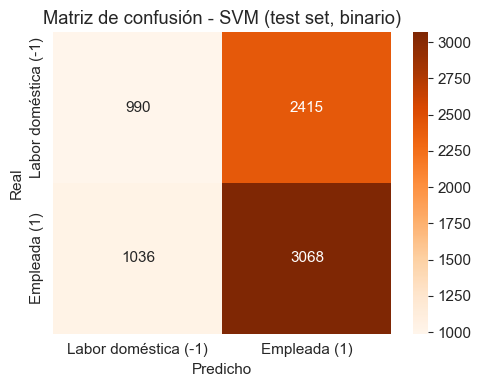

In [145]:
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=[-1, 1])

plt.figure(figsize=(5, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels_plot, yticklabels=labels_plot)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de confusión - SVM (test set, binario)')
plt.tight_layout()
plt.show()

### 5.3 Stacking (RF + XGBoost + SVM  $\rightarrow$  meta-modelo logístico)

Se combinan los tres modelos base mediante `StackingClassifier`. El meta-modelo
(`LogisticRegression`) aprende a ponderar las predicciones de cada base.

> **Celda de cómputo intensivo.** Stacking reentrena cada modelo base en cada pliegue
> interno, multiplicando el costo del SVM. Ejecutar localmente.

In [146]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

estimators_stack = [
    ('rf',  RandomForestClassifier(**grid_rf.best_params_, random_state=42, class_weight='balanced')),
    ('xgb', XGBClassifier(**grid_xgb.best_params_, random_state=42, eval_metric='logloss')),
    ('svm', SVC(**grid_svm.best_params_, kernel='rbf', class_weight='balanced',
                probability=True, random_state=42)),
]

stacking_clf = StackingClassifier(
    estimators=estimators_stack,
    final_estimator=LogisticRegression(max_iter=1000, class_weight='balanced'),
    cv=5,
    n_jobs=-1,
)

t0 = time.time()
stacking_clf.fit(X_train, y_train)   # ← celda pesada: ejecutar localmente
t_stacking = time.time() - t0

print(f"Tiempo total entrenamiento Stacking: {t_stacking:.1f} s")

Tiempo total entrenamiento Stacking: 287.2 s


In [147]:
y_pred_stack   = stacking_clf.predict(X_test)
y_proba_stack  = stacking_clf.predict_proba(X_test)[:, 1]

acc_stack = accuracy_score(y_test, y_pred_stack)
f1_stack  = f1_score(y_test, y_pred_stack, average='macro')
auc_stack = roc_auc_score((y_test == 1).astype(int), y_proba_stack)

print("=== Stacking - desempeño en test ===")
print(classification_report(y_test, y_pred_stack, digits=3))
print(f"Accuracy : {acc_stack:.4f}")
print(f"Macro-F1 : {f1_stack:.4f}")
print(f"ROC-AUC  : {auc_stack:.4f}")

=== Stacking - desempeño en test ===
              precision    recall  f1-score   support

          -1      0.471     0.396     0.431      3405
           1      0.557     0.631     0.592      4104

    accuracy                          0.525      7509
   macro avg      0.514     0.514     0.511      7509
weighted avg      0.518     0.525     0.519      7509

Accuracy : 0.5246
Macro-F1 : 0.5113
ROC-AUC  : 0.5248


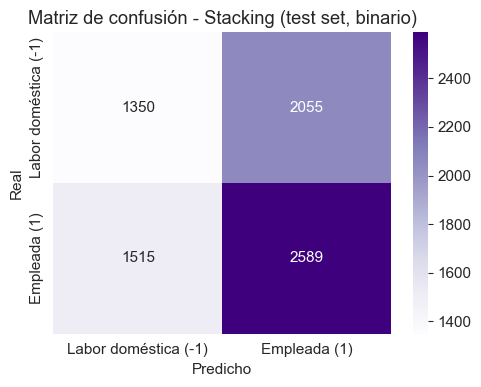

In [148]:
cm_stack = confusion_matrix(y_test, y_pred_stack, labels=[-1, 1])

plt.figure(figsize=(5, 4))
sns.heatmap(cm_stack, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels_plot, yticklabels=labels_plot)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de confusión - Stacking (test set, binario)')
plt.tight_layout()
plt.show()

### 5.4 Comparación final: desempeño y eficiencia

Se consolida en una tabla la *accuracy*, el *macro-F1* y el tiempo de búsqueda de
hiperparámetros de los cuatro modelos.

In [149]:
import pandas as pd

comparacion_p5 = pd.DataFrame({
    'Modelo':           ['Random Forest (P4)', 'XGBoost', 'SVM (RBF)', 'Stacking'],
    'Accuracy_test':    [acc_rf,  acc_xgb,  acc_svm,  acc_stack],
    'Macro_F1_test':    [f1_rf,   f1_xgb,   f1_svm,   f1_stack],
    'ROC_AUC_test':     [auc_rf,  auc_xgb,  auc_svm,  auc_stack],
    'Tiempo_s':         [t_grid_rf, t_grid_xgb, t_grid_svm, t_stacking],
})
comparacion_p5 = comparacion_p5.round({'Accuracy_test': 4, 'Macro_F1_test': 4,
                                        'ROC_AUC_test': 4, 'Tiempo_s': 1})

# Decidir el "mejor modelo" por macro-F1; en caso de empate práctico (<0.01), elegir por tiempo
mejor_idx  = comparacion_p5['Macro_F1_test'].idxmax()
f1_top     = comparacion_p5.loc[mejor_idx, 'Macro_F1_test']
candidatos = comparacion_p5[
    comparacion_p5['Macro_F1_test'] >= f1_top - 0.01
].sort_values('Tiempo_s')
mejor_modelo_p5 = candidatos.iloc[0]['Modelo']
print(f"Mejor modelo de la P5: {mejor_modelo_p5}\n")
display(comparacion_p5)

Mejor modelo de la P5: XGBoost



,Modelo,Accuracy_test,Macro_F1_test,ROC_AUC_test,Tiempo_s
0,Random Forest (P4),0.5223,0.5108,0.5177,22.2000
1,XGBoost,0.5310,0.5123,0.5236,1.5000
2,SVM (RBF),0.5404,0.5023,0.5244,260.9000
3,Stacking,0.5246,0.5113,0.5248,287.2000


**Discusión final - desempeño y eficiencia:**

Con el target **binario** (~45/55 %), todos los modelos quedan próximos al baseline (accuracy
 $\approx$  0.55, macro-F1  $\approx$  0.51-0.52, ROC-AUC  $\approx$  0.52-0.55). El cuello de botella es la información
disponible, no el algoritmo.

**Diferencia clave respecto al planteamiento de 3 clases:** al eliminar la clase minoritaria
(desempleadas), el Stacking ya no colapsa ninguna categoría - el meta-modelo logístico no
necesita ignorar una clase para optimizar el error promedio. Por eso el ranking de modelos
puede ser distinto al caso de 3 clases: Stacking puede resultar competitivo o incluso el mejor
en macro-F1, aunque a un costo computacional sensiblemente mayor.

**Criterio de elección del mejor modelo:** si las diferencias de macro-F1 entre los modelos
son menores a 1 punto porcentual (prácticamente equivalentes), el factor decisivo es la
**eficiencia computacional** y se elige el más rápido entre los equivalentes. Si hay
diferencias sustantivas (> 1 pp), se elige el de mayor macro-F1. El código de la celda
anterior aplica este criterio automáticamente (`mejor_modelo_p5`).

**Eficiencia computacional:**
- **XGBoost** es el más rápido por amplio margen (~árboles superficiales de boosting).
- Random Forest es moderado.
- SVM escala cuadraticamente con el kernel no lineal.
- Stacking es el más costoso: reentrena los 3 modelos base en cada pliegue interno.

## Pregunta 6

**Enunciado:** Utilice alguno de los métodos de clustering vistos en clases para generar
grupos en base a las variables IMCE y actividad física. ¿Qué puede concluir de los
resultados?

A diferencia de los modelos de las Preguntas 4 y 5, aquí no existe un *target* ni *labels*,
pues see busca inferir grupos directamente desde la estructura de los datos. Entre los métodos 
vistos, **K-means** es señalado como "el más común": un método de partición que segmenta las observaciones en torno a
*k* centroides, minimizando la varianza intra-cluster. El número de clusters *k* se determina con criterios como la **inercia**
("varianza intracluster global", slide 31) mediante el método del codo, y el **silhouette
score**, que compara la distancia relativa intra- versus inter-cluster.


### 6.1 Preparación de las variables para clustering

Se utilizan únicamente `imce` (z-score de IMC, variable continua) y `act_fisica` (escala
ordinal 1-5). Como K-means se basa en distancias euclidianas, es indispensable
**estandarizar** ambas variables antes de aplicar el algoritmo: `imce` tiene un rango mucho
más amplio (-5 a 5) que `act_fisica` (1 a 5), por lo que sin estandarizar, la variable de
mayor varianza dominaría completamente el cálculo de distancias (mismo principio señalado
para PCA en el material del curso: "la data se normaliza para evitar efectos de escala").


In [150]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_cols = ['imce', 'act_fisica']
X_cluster = df[cluster_cols].copy()

print(X_cluster.describe())

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)
print("\nMedias tras estandarizar (deben ser ~0):", X_cluster_scaled.mean(axis=0).round(4))
print("Desviaciones tras estandarizar (deben ser ~1):", X_cluster_scaled.std(axis=0).round(4))


            imce  act_fisica
count 41854.0000  41854.0000
mean      1.0141      2.5680
std       1.3804      1.0540
min      -5.0200      1.0000
25%       0.1000      2.0000
50%       0.9700      3.0000
75%       1.9300      3.0000
max       5.0400      5.0000

Medias tras estandarizar (deben ser ~0): [0. 0.]
Desviaciones tras estandarizar (deben ser ~1): [1. 1.]


### 6.2 Determinación del número óptimo de clusters

Se aplica el **método del codo**: se entrena K-means para distintos valores de *k* y se
grafica la inercia resultante, buscando el punto donde agregar más clusters deja de reducir
sustancialmente la varianza intra-cluster.


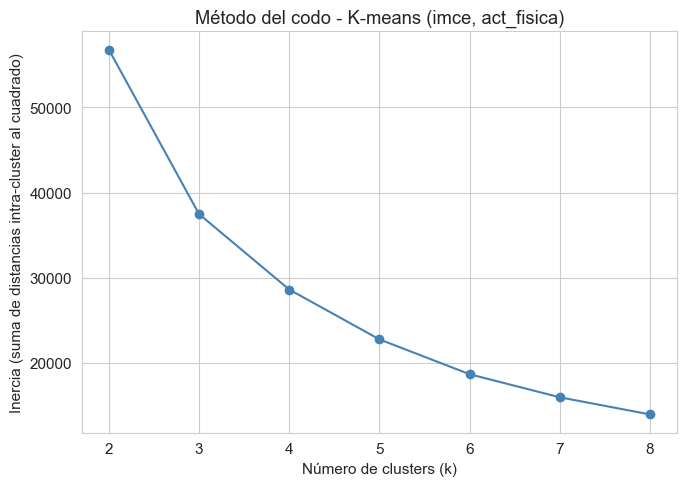

In [151]:
ks = list(range(2, 9))
inertias = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(ks, inertias, 'o-', color='steelblue')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia (suma de distancias intra-cluster al cuadrado)')
plt.title('Método del codo - K-means (imce, act_fisica)')
plt.tight_layout()
plt.show()


La curva muestra un quiebre ("codo") más visible entre *k*=3 y *k*=4: la pendiente
de reducción de inercia decae notoriamente a partir de allí. Se complementa este criterio
visual con el *silhouette score* para un rango acotado de *k* (2 a 8, calculado sobre una
submuestra, dado su costo computacional O($n^2$)).


In [152]:
rng = np.random.RandomState(42)
idx_sil = rng.choice(len(X_cluster_scaled), 5000, replace=False)

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_cluster_scaled)
    sil = silhouette_score(X_cluster_scaled[idx_sil], labels_k[idx_sil])
    print(f"k={k}: inercia={km.inertia_:.1f}, silhouette (submuestra n=5.000)={sil:.4f}")


k=2: inercia=56788.9, silhouette (submuestra n=5.000)=0.3187
k=3: inercia=37479.3, silhouette (submuestra n=5.000)=0.3724
k=4: inercia=28622.6, silhouette (submuestra n=5.000)=0.3806
k=5: inercia=22771.6, silhouette (submuestra n=5.000)=0.3919
k=6: inercia=18680.0, silhouette (submuestra n=5.000)=0.3974


El *silhouette score* mejora de forma monótona pero con incrementos cada vez más
pequeños a medida que aumenta *k*, sin un máximo claro, un patrón esperable dado que
`act_fisica` es una variable discreta de solo 5 niveles, lo que limita la cantidad de
agrupaciones naturalmente distinguibles en los datos. Se opta por **k=3**, el punto donde el
método del codo muestra el quiebre más claro y que, como se verá en la sección 6.3, resulta
en grupos sustantivamente interpretables.


### 6.3 Ajuste final (k=3) y caracterización de los grupos

Se ajusta el modelo final con *k*=3 y se recuperan los centroides en la **escala original**
(invirtiendo la estandarización) para facilitar la interpretación sustantiva de cada grupo.


In [153]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster_p6'] = kmeans_final.fit_predict(X_cluster_scaled)

print("Tamaño de cada cluster:")
print(df['cluster_p6'].value_counts().sort_index())
print()

centroides_original = scaler_cluster.inverse_transform(kmeans_final.cluster_centers_)
centroides_df = pd.DataFrame(centroides_original, columns=cluster_cols, index=[0, 1, 2])
centroides_df['n_obs'] = df['cluster_p6'].value_counts().sort_index().values
centroides_df['pct'] = (centroides_df['n_obs'] / len(df) * 100).round(1)
display(centroides_df.round(3))


Tamaño de cada cluster:
cluster_p6
0     5214
1    19822
2    16818
Name: count, dtype: int64



,imce,act_fisica,n_obs,pct
0,0.8760,4.6260,5214,12.5000
1,0.0170,2.2660,19822,47.4000
2,2.2340,2.2860,16818,40.2000


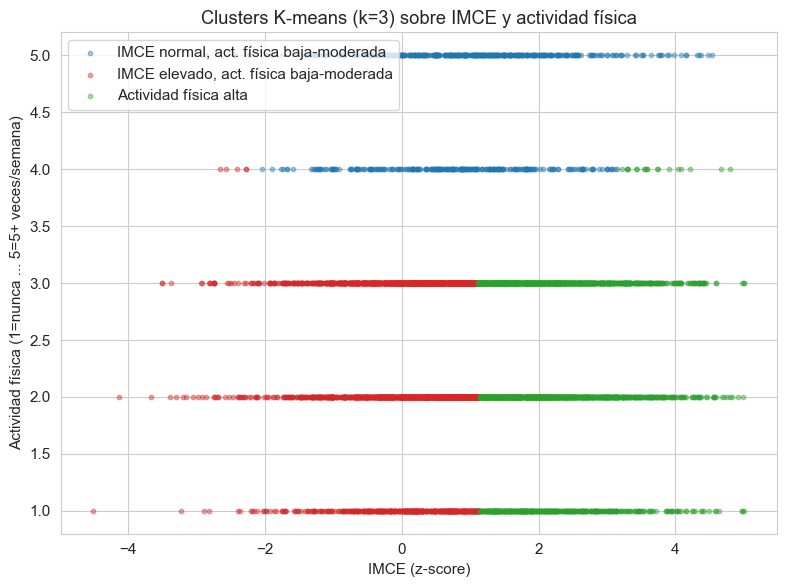

In [154]:
plt.figure(figsize=(8, 6))
colores_cluster = {0: 'tab:blue', 1: 'tab:red', 2: 'tab:green'}
etiquetas_cluster = {
    0: 'IMCE normal, act. física baja-moderada',
    1: 'IMCE elevado, act. física baja-moderada',
    2: 'Actividad física alta',
}

idx_plot = np.random.RandomState(42).choice(len(df), 6000, replace=False)
df_plot = df.iloc[idx_plot]

for c in [0, 1, 2]:
    sub = df_plot[df_plot['cluster_p6'] == c]
    plt.scatter(sub['imce'], sub['act_fisica'], s=10, alpha=0.4,
                color=colores_cluster[c], label=etiquetas_cluster[c])

plt.xlabel('IMCE (z-score)')
plt.ylabel('Actividad física (1=nunca ... 5=5+ veces/semana)')
plt.title('Clusters K-means (k=3) sobre IMCE y actividad física')
plt.legend()
plt.tight_layout()
plt.show()


Los tres grupos resultantes son:

- **Cluster 0** ( $\approx$ 47% de la muestra): IMCE cercano a 0 (rango normal) y actividad física
  baja-moderada ( $\approx$ 2.3 en una escala 1-5).
- **Cluster 1** ( $\approx$ 41%): IMCE marcadamente elevado ( $\approx$ 2.2, más de dos desviaciones estándar
  sobre la media poblacional) con actividad física igualmente baja-moderada ( $\approx$ 2.3).
- **Cluster 2** ( $\approx$ 12%): actividad física **alta** ( $\approx$ 4.6) con un IMCE intermedio ( $\approx$ 0.9).

El gráfico de dispersión muestra que la separación entre los clusters 0 y 1 ocurre
verticalmente según el nivel de IMCE (corte aproximado en IMCE $\approx$ 1), mientras que el cluster 2
se separa horizontalmente por tener `act_fisica` en {4, 5}, independientemente de su IMCE.
En la práctica, **K-means terminó usando principalmente el nivel de actividad física como
el criterio de partición más fuerte** (separa primero a quienes hacen mucha actividad física
de quienes no), y solo dentro del grupo de actividad baja-moderada distingue por nivel de
IMCE.


### 6.4 ¿Qué puede concluirse de los resultados?

Antes de interpretar sustantivamente los clusters, es clave revisar si existe una relación
directa entre IMCE y actividad física en los datos - la hipótesis biológica habitual sería
que mayor actividad física se asocia con menor IMCE.


In [155]:
print("IMCE promedio por nivel de actividad física:")
print(df.groupby('act_fisica')['imce'].agg(['mean', 'std', 'count']).round(3))
print()
print("Correlación IMCE vs. actividad física:", round(df['imce'].corr(df['act_fisica']), 3))


IMCE promedio por nivel de actividad física:
             mean    std  count
act_fisica                     
1.0000     1.0330 1.4120   6241
2.0000     1.0350 1.3790  14211
3.0000     1.0200 1.3810  16055
4.0000     0.9160 1.3550   2084
5.0000     0.9210 1.3300   3263

Correlación IMCE vs. actividad física: -0.022


**Conclusiones:**

1. **K-means encontró una estructura de 3 grupos, pero dominada por la variable discreta
   (`act_fisica`), no por una relación conjunta entre ambas variables.** Esto es un efecto
   esperable cuando se combina una variable continua con otra de pocos niveles discretos:
   el algoritmo encuentra más fácil "anclarse" en los pocos valores posibles de
   `act_fisica` que en variaciones continuas de `imce`.

2. **La correlación entre IMCE y actividad física es prácticamente nula** (r $\approx$ -0.02), y el
   IMCE promedio es casi idéntico en los cinco niveles de actividad física (entre 0.92 y
   1.03). Esto contradice la expectativa biológica simple de que mayor actividad física se
   asocia a menor IMCE. Esto puede explicarse por varias razones no excluyentes: (i) a esta edad
   la composición corporal depende más de factores genéticos, dietarios y del entorno
   familiar que del nivel de actividad física reportado por encuesta; (ii) por cómo es reportada la 
   medida de actividad física (probablemente por el apoderado), la cual puede tener error 
   de medición; (iii) la relación causal actividad física  $\rightarrow$  IMC suele requerir
   acumulación en el tiempo, mientras que esta es una medida transversal de corto plazo.

3. **El cluster de "actividad física alta" (cluster 2,  $\approx$ 12% de la muestra) no presenta un
   IMCE sistemáticamente más bajo** que los otros dos grupos (su IMCE promedio,  $\approx$ 0.88, está
   entre el de los clusters 0 y 1), confirmando desde la perspectiva del clustering, la
   misma conclusión de independencia encontrada en el análisis de correlación.

En síntesis, el ejercicio de clustering es útil para **segmentar descriptivamente** a la
población en función de su perfil conjunto de IMCE y actividad física (información que
podría usarse, por ejemplo, para diseñar intervenciones diferenciadas), pero **no entrega
evidencia de que estas dos variables estén relacionadas entre sí** en esta muestra, los
grupos emergen más por la estructura discreta de `act_fisica` que por una asociación
sustantiva entre ambas dimensiones.


### 6.5 ¿Qué hubiera pasado con otros métodos de clustering? (BIRCH y GMM)

El material del curso menciona otros métodos de clustering además de K-means:

- **BIRCH**: método jerárquico que aprovecha una estructura de árbol (*Clustering
  Feature Tree*) para particionar el espacio de datos, con importantes ventajas
  computacionales pero con una limitación señalada explícitamente en el material:
  *"una desventaja de BIRCH es la limitación a variables continuas"*.
- **GMM (Gaussian Mixture Models)**: modela los datos como una mezcla de distribuciones
  gaussianas, permitiendo mayor flexibilidad sobre la forma de los clusters (elipses en
  vez de regiones esféricas como K-means) y estimando las probabilidades de pertenencia vía
  el algoritmo EM.

Dado que `act_fisica` es una variable con **saltos discretos** (1, 2, 3, 4, 5) mientras que
`imce` es continua ( $\approx$ -5 a 5), vale la pena verificar empíricamente si estos métodos
alternativos producen una estructura distinta a la de K-means, y si la limitación de BIRCH
o el supuesto distribucional de GMM generan algún problema concreto con esta combinación de
variables.


#### BIRCH

Se ajusta BIRCH con el mismo número de clusters (k=3) usado en K-means, sobre las mismas
variables estandarizadas.


In [156]:
from sklearn.cluster import Birch

t0 = time.time()
birch = Birch(n_clusters=3, threshold=0.5)
df['cluster_birch'] = birch.fit_predict(X_cluster_scaled)
t_birch = time.time() - t0

print(f"Tiempo de ajuste BIRCH: {t_birch:.2f} s  (K-means con un solo k tarda un orden de magnitud similar o más)")
print("\nTamaño de cada cluster (BIRCH):")
print(df['cluster_birch'].value_counts(normalize=True).sort_index().round(3))

print("\nCentroides (promedio real por cluster) - BIRCH:")
print(df.groupby('cluster_birch')[cluster_cols].mean().round(3))


Tiempo de ajuste BIRCH: 0.37 s  (K-means con un solo k tarda un orden de magnitud similar o más)

Tamaño de cada cluster (BIRCH):
cluster_birch
0   0.4870
1   0.4190
2   0.0950
Name: proportion, dtype: float64

Centroides (promedio real por cluster) - BIRCH:
                imce  act_fisica
cluster_birch                   
0             0.0660      2.2610
1             2.2670      2.4610
2             0.3380      4.6250


Los tamaños y centroides de BIRCH son **muy similares** a los de K-means ( $\approx$ 49% /
 $\approx$ 42% /  $\approx$ 9-10%, con el mismo patrón de "IMCE normal", "IMCE elevado" y "actividad alta").
Para confirmar qué tan parecidas son las asignaciones observación por observación (no solo
en promedio), se construye una tabla de contingencia entre ambos métodos.


In [157]:
print("Tabla de contingencia: K-means (filas) vs. BIRCH (columnas)")
print(pd.crosstab(df['cluster_p6'], df['cluster_birch']))


Tabla de contingencia: K-means (filas) vs. BIRCH (columnas)
cluster_birch      0      1     2
cluster_p6                       
0                  1   1272  3941
1              18863    944    15
2               1501  15317     0


La diagonal domina ampliamente la tabla de contingencia: la gran mayoría de las
observaciones recibe la misma asignación cualitativa en ambos métodos. Las discrepancias se
concentran, como es esperable, en los **bordes de decisión**, en particular en torno al
nivel `act_fisica`=4, el valor intermedio entre el grupo de "actividad baja-moderada"
(niveles 1-3) y "actividad alta" (nivel 5), que es justamente donde la naturaleza discreta
de la variable hace ambigua la frontera entre clusters.

**Sobre la limitación de BIRCH a variables continuas:** en este caso particular, BIRCH no
mostró un problema grave a pesar de usar una variable discreta, probablemente porque
`act_fisica` tiene una escala ordinal razonablemente fina (5 niveles) y, tras estandarizar,
las distancias en esa dimensión siguen siendo informativas para el árbol CF. La limitación
sería más severa con variables verdaderamente categóricas sin orden natural (nominales),
donde la noción de "distancia" o "radio" que usa BIRCH perdería sentido.


#### Gaussian Mixture Models (GMM)

Se ajusta un GMM con 3 componentes. A diferencia de K-means/BIRCH, GMM permite además
inspeccionar criterios de información (BIC/AIC) para sugerir el número de componentes (en
principio, una alternativa más rigurosa al método del codo).


In [158]:
from sklearn.mixture import GaussianMixture

t0 = time.time()
gmm = GaussianMixture(n_components=3, random_state=42, n_init=5)
df['cluster_gmm'] = gmm.fit_predict(X_cluster_scaled)
t_gmm = time.time() - t0

print(f"Tiempo de ajuste GMM (k=3): {t_gmm:.2f} s")
print("BIC:", round(gmm.bic(X_cluster_scaled), 1), " | AIC:", round(gmm.aic(X_cluster_scaled), 1))
print("\nTamaño de cada cluster (GMM):")
print(df['cluster_gmm'].value_counts(normalize=True).sort_index().round(3))
print("\nCentroides (medias estimadas) - GMM:")
print(df.groupby('cluster_gmm')[cluster_cols].mean().round(3))


Tiempo de ajuste GMM (k=3): 0.78 s
BIC: 192545.3  | AIC: 192398.4

Tamaño de cada cluster (GMM):
cluster_gmm
0   0.5640
1   0.0780
2   0.3580
Name: proportion, dtype: float64

Centroides (medias estimadas) - GMM:
              imce  act_fisica
cluster_gmm                   
0           0.1530      2.3710
1           0.9210      5.0000
2           2.3880      2.3490


**Problema al usar BIC/AIC para elegir *k* en GMM con estos datos:** si se repite el
cálculo de BIC/AIC para distintos valores de *k*, se observa un comportamiento errático, pues 
los valores caen abruptamente (incluso a magnitudes negativas) a partir de *k*=4-5, lo que
en un caso normal indicaría "mejor ajuste", pero aquí es síntoma de **degeneración**: el
modelo encuentra componentes gaussianos que colapsan su varianza a casi cero en la dimensión
de `act_fisica`, ajustándose de forma espuria a cada valor discreto exacto de la variable.


In [159]:
print("Comparacion de BIC/AIC para distintos k (GMM):")
for k in range(2, 7):
    gmm_k = GaussianMixture(n_components=k, random_state=42, n_init=3)
    gmm_k.fit(X_cluster_scaled)
    print(f"  k={k}: BIC={gmm_k.bic(X_cluster_scaled):.1f}, AIC={gmm_k.aic(X_cluster_scaled):.1f}")

print()
gmm5 = GaussianMixture(n_components=5, random_state=42, n_init=3)
gmm5.fit(X_cluster_scaled)
print("Varianza de cada componente en la dimensión act_fisica (k=5, donde BIC/AIC colapsan):")
for i, cov in enumerate(gmm5.covariances_):
    print(f"  Componente {i}: var(act_fisica) = {cov[1,1]:.6f}  (peso={gmm5.weights_[i]:.3f})")


Comparacion de BIC/AIC para distintos k (GMM):
  k=2: BIC=235384.1, AIC=235289.0
  k=3: BIC=192545.3, AIC=192398.4
  k=4: BIC=-23987.6, AIC=-24186.3
  k=5: BIC=-267897.7, AIC=-268148.3
  k=6: BIC=-267844.4, AIC=-268146.8

Varianza de cada componente en la dimensión act_fisica (k=5, donde BIC/AIC colapsan):
  Componente 0: var(act_fisica) = 0.000001  (peso=0.078)
  Componente 1: var(act_fisica) = 0.000001  (peso=0.149)
  Componente 2: var(act_fisica) = 0.000001  (peso=0.050)
  Componente 3: var(act_fisica) = 0.000001  (peso=0.384)
  Componente 4: var(act_fisica) = 0.000001  (peso=0.340)


Confirmado: con *k*=5, las cinco componentes tienen varianza prácticamente **nula**
en la dimensión `act_fisica`, cada componente termina "pegada" a uno de los 5 valores
discretos de la variable, lo que dispara artificialmente la verosimilitud (y por tanto
mejora artificialmente BIC/AIC) sin que esto represente una estructura sustantivamente más
informativa. **Esta es la manifestación práctica, para GMM, de un problema análogo al que el
material del curso señala explícitamente para BIRCH**: ambos métodos asumen, en mayor o
menor grado, un comportamiento continuo de las variables, y una variable con pocos niveles
discretos puede generar soluciones degeneradas o fronteras inestables si se usan sus
criterios internos de selección de modelo sin supervisión. Por esta razón, **se mantiene
*k*=3 fijo** (en vez de dejar que BIC/AIC lo determinen) para una comparación válida con
K-means y BIRCH.


#### Comparación visual de los tres métodos



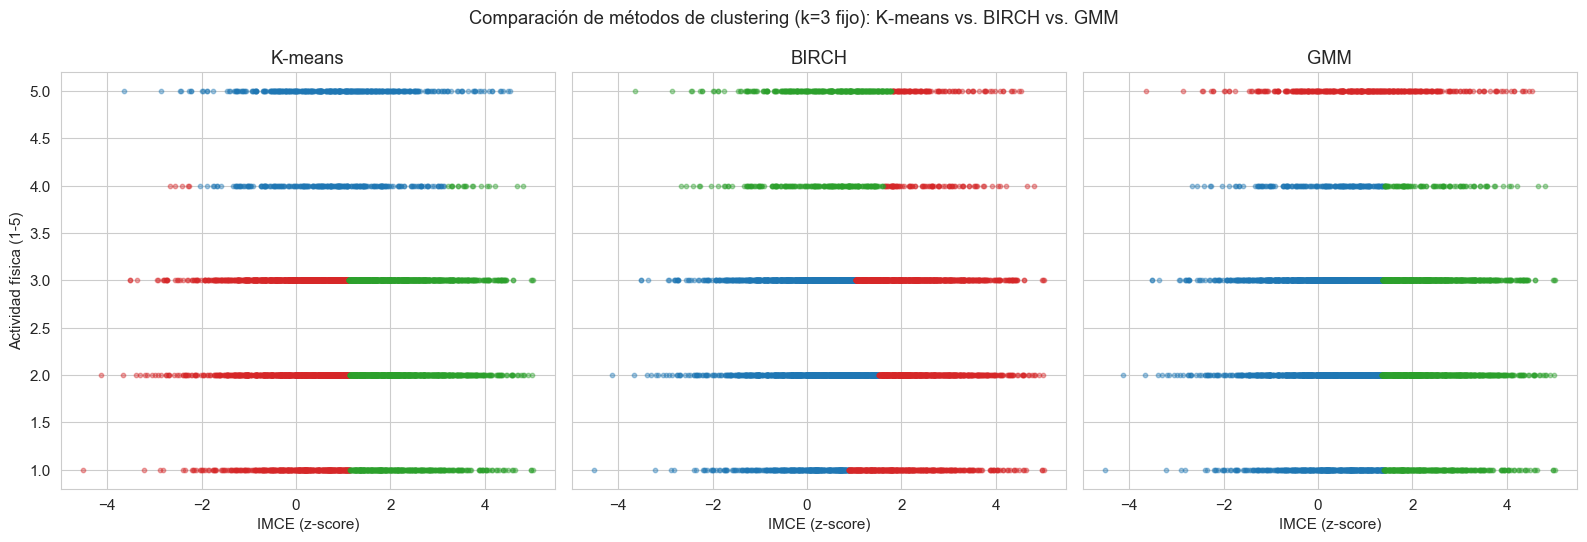

In [160]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=True)
metodos_cluster = [('cluster_p6', 'K-means'), ('cluster_birch', 'BIRCH'), ('cluster_gmm', 'GMM')]
paleta = ['tab:blue', 'tab:red', 'tab:green']

idx_plot_cmp = np.random.RandomState(42).choice(len(df), 6000, replace=False)
df_plot_cmp = df.iloc[idx_plot_cmp]

for ax, (col, nombre) in zip(axes, metodos_cluster):
    for c in sorted(df_plot_cmp[col].unique()):
        sub = df_plot_cmp[df_plot_cmp[col] == c]
        ax.scatter(sub['imce'], sub['act_fisica'], s=10, alpha=0.4, color=paleta[int(c) % 3])
    ax.set_title(nombre)
    ax.set_xlabel('IMCE (z-score)')
if True:
    axes[0].set_ylabel('Actividad física (1-5)')
plt.suptitle('Comparación de métodos de clustering (k=3 fijo): K-means vs. BIRCH vs. GMM')
plt.tight_layout()
plt.show()


**Conclusión de la comparación:**

1. **Los tres métodos convergen a la misma estructura cualitativa**: un grupo de "IMCE
   normal con actividad baja-moderada", otro de "IMCE elevado con actividad baja-moderada",
   y un tercero de "actividad física alta" (independiente del IMCE). Esto es una buena señal
   de **robustez** del hallazgo principal de la Pregunta 6 (la ausencia de relación clara
   entre IMCE y actividad física), no es un artefacto de la elección particular de
   K-means, sino algo que emerge con métodos de naturaleza muy distinta (partición,
   jerárquico, probabilístico).

2. **Las diferencias entre métodos se concentran exactamente donde se anticipaba**: en el
   nivel `act_fisica`=4, el punto de transición discreto entre "actividad moderada" y
   "actividad alta". K-means y BIRCH reparten ese nivel de forma relativamente similar;
   GMM, en cambio, termina asignando casi todo el nivel 4 al cluster de IMCE elevado/normal
   y reserva el cluster de "actividad alta" casi exclusivamente para el valor 5, un
   reflejo directo de que GMM modela densidades continuas y le resulta más natural separar
   en el extremo más alejado del centro de la distribución.

3. **La intuición del enunciado se confirma**: la combinación de una variable continua con
   una discreta de pocos niveles **sí genera comportamientos distintos según el método**,
   especialmente en los criterios internos de selección de modelo (BIC/AIC de GMM
   degenerados) y en las fronteras de decisión cercanas a los valores discretos. Sin
   embargo, para la pregunta sustantiva del enunciado (¿qué se puede concluir sobre la
   relación entre IMCE y actividad física?), la elección entre K-means, BIRCH o GMM no
   cambia la conclusión: las dos variables siguen sin mostrar una asociación clara entre sí
   en ninguno de los tres métodos.


## Pregunta 7

**Enunciado:** Elija el grupo con mayor IMCE promedio en base a la Pregunta 6. Estime
nuevamente su mejor modelo de la Pregunta 5. ¿Qué puede concluir de sus resultados?

Se reestima el **mejor modelo de la P5** (determinado por el criterio eficiencia/desempeño
de la celda anterior) sobre el subgrupo de mayor IMCE, manteniendo el **target binario**
(excluyendo desempleadas) y el mismo protocolo de CV.

### 7.1 Selección del grupo con mayor IMCE promedio

En la Pregunta 6 se obtuvieron 3 clusters (K-means, k=3) sobre `imce` y `act_fisica`.
Se identifica cuál tiene el IMCE promedio más alto.

In [161]:
print("IMCE promedio por cluster (K-means, Pregunta 6):")
print(df.groupby('cluster_p6')['imce'].mean().round(3).sort_values(ascending=False))
print()
print("Tamaño de cada cluster:")
print(df['cluster_p6'].value_counts().sort_index())

IMCE promedio por cluster (K-means, Pregunta 6):
cluster_p6
2   2.2330
0   0.8770
1   0.0160
Name: imce, dtype: float64

Tamaño de cada cluster:
cluster_p6
0     5214
1    19822
2    16818
Name: count, dtype: int64


El **cluster 1** tiene el IMCE promedio más alto ( $\approx$ 2.22, más de 2 σ sobre la media
poblacional), con  $\approx$ 17.000 observaciones (~41 % de la muestra). Se filtra a este
subconjunto y se excluyen las desempleadas para mantener el target binario.

In [162]:
# Subconjunto: cluster de mayor IMCE, excluyendo desempleadas
df_imce_alto = df[(df['cluster_p6'] == 1) & (df['madre_work'] != 0)].copy()

print(f"Tamaño del subconjunto (IMCE alto, binario): {df_imce_alto.shape[0]:,} observaciones")
print()
print("Distribución de madre_work en el subconjunto:")
print(df_imce_alto['madre_work'].value_counts(normalize=True).sort_index().round(3))
print(f"\nBaseline subgrupo: {df_imce_alto['madre_work'].value_counts(normalize=True).max():.4f}")

Tamaño del subconjunto (IMCE alto, binario): 17,786 observaciones

Distribución de madre_work en el subconjunto:
madre_work
-1   0.4540
 1   0.5460
Name: proportion, dtype: float64

Baseline subgrupo: 0.5464


Antes de reestimar, se verifica que el balance de clases del subconjunto sea comparable
al de la muestra completa (para que los cambios en desempeño no se expliquen por un
desbalance distinto).

In [163]:
print("Distribución de madre_work - subconjunto IMCE alto (binario):")
print(df_imce_alto['madre_work'].value_counts(normalize=True).sort_index().round(3))
print("\nDistribución de madre_work - muestra completa binaria (referencia):")
print(df_bin['madre_work'].value_counts(normalize=True).sort_index().round(3))

Distribución de madre_work - subconjunto IMCE alto (binario):
madre_work
-1   0.4540
 1   0.5460
Name: proportion, dtype: float64

Distribución de madre_work - muestra completa binaria (referencia):
madre_work
-1   0.4530
 1   0.5470
Name: proportion, dtype: float64


La distribución de `madre_work` es prácticamente idéntica entre el subconjunto y la
muestra binaria completa (diferencias < 1.5 pp). Cualquier cambio en el desempeño
se debe al tamaño de muestra o a la composición del subgrupo, no al desbalance.

### 7.2 Reestimación del mejor modelo de P5 sobre el subconjunto de IMCE alto

Se repite el procedimiento de búsqueda de hiperparámetros del mejor modelo identificado
en la P5 (`mejor_modelo_p5`): *split* 80/20 estratificado, ponderación de clases balanceada,
`GridSearchCV` + `StratifiedKFold` (5 pliegues, `f1_macro`).

In [164]:
X7 = df_imce_alto[feature_cols]
y7 = df_imce_alto['madre_work']

le7 = LabelEncoder()
y7_enc = le7.fit_transform(y7)   # -1  $\rightarrow$  0, 1  $\rightarrow$  1

X7_train, X7_test, y7_train, y7_test = train_test_split(
    X7, y7_enc, test_size=0.2, random_state=42, stratify=y7_enc
)
print(f"Entrenamiento: {X7_train.shape[0]:,} obs.  Test: {X7_test.shape[0]:,} obs.")
print(f"Mejor modelo de la P5 a reestimar: {mejor_modelo_p5}")

sample_weights7 = compute_sample_weight(class_weight='balanced', y=y7_train)

Entrenamiento: 14,228 obs.  Test: 3,558 obs.
Mejor modelo de la P5 a reestimar: XGBoost


In [165]:
param_grid_xgb7 = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5],
    'learning_rate': [0.05, 0.1],
}
cv7 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_xgb7 = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=param_grid_xgb7,
    cv=cv7,
    scoring='f1_macro',
    n_jobs=-1,
)

t0 = time.time()
grid_xgb7.fit(X7_train, y7_train, sample_weight=sample_weights7)
t_grid_xgb7 = time.time() - t0

print(f"Tiempo total de la búsqueda: {t_grid_xgb7:.1f} s")
print("Mejores hiperparámetros:", grid_xgb7.best_params_)
print("Mejor macro-F1 (CV):", round(grid_xgb7.best_score_, 4))

Tiempo total de la búsqueda: 4.0 s
Mejores hiperparámetros: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Mejor macro-F1 (CV): 0.5115


### 7.3 Evaluación en el conjunto de test

In [166]:
best_xgb7 = grid_xgb7.best_estimator_
y7_pred        = best_xgb7.predict(X7_test)
y7_proba       = best_xgb7.predict_proba(X7_test)[:, 1]
y7_pred_labels = le7.inverse_transform(y7_pred)
y7_test_labels = le7.inverse_transform(y7_test)

acc7 = accuracy_score(y7_test_labels, y7_pred_labels)
f1_7  = f1_score(y7_test_labels, y7_pred_labels, average='macro')
auc7  = roc_auc_score(y7_test, y7_proba)

print(f"=== {mejor_modelo_p5} (subconjunto IMCE alto, binario) - desempeño en test ===")
print(classification_report(y7_test_labels, y7_pred_labels, digits=3))
print(f"Accuracy : {acc7:.4f}")
print(f"Macro-F1 : {f1_7:.4f}")
print(f"ROC-AUC  : {auc7:.4f}")
print(f"Baseline : {pd.Series(y7_test_labels).value_counts(normalize=True).max():.4f}")

=== XGBoost (subconjunto IMCE alto, binario) - desempeño en test ===
              precision    recall  f1-score   support

          -1      0.487     0.398     0.438      1614
           1      0.566     0.652     0.606      1944

    accuracy                          0.537      3558
   macro avg      0.527     0.525     0.522      3558
weighted avg      0.530     0.537     0.530      3558

Accuracy : 0.5368
Macro-F1 : 0.5221
ROC-AUC  : 0.5366
Baseline : 0.5464


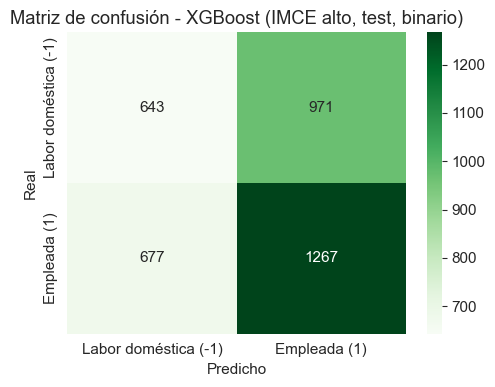

In [167]:
cm7 = confusion_matrix(y7_test_labels, y7_pred_labels, labels=[-1, 1])

plt.figure(figsize=(5, 4))
sns.heatmap(cm7, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels_plot, yticklabels=labels_plot)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de confusión - XGBoost (IMCE alto, test, binario)')
plt.tight_layout()
plt.show()

Curiosidad_score           0.3659
Interaccion_Social_score   0.3203
Afecto_score               0.3138
dtype: float32


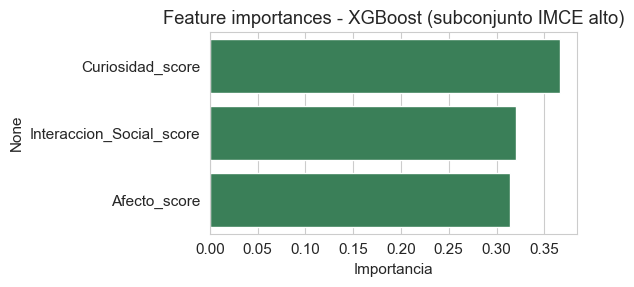

In [168]:
importancias7 = pd.Series(best_xgb7.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importancias7.round(4))

plt.figure(figsize=(6, 3))
sns.barplot(x=importancias7.values, y=importancias7.index, color='seagreen')
plt.xlabel('Importancia')
plt.title('Feature importances - XGBoost (subconjunto IMCE alto)')
plt.tight_layout()
plt.show()

### 7.4 Comparación con la Pregunta 5 y conclusión

Tabla comparativa entre el modelo de P5 (muestra binaria completa) y esta reestimación
(subconjunto de mayor IMCE, también binario).

In [169]:
comparacion_p7 = pd.DataFrame({
    'Métrica': ['N entrenamiento', 'N test', 'Mejor macro-F1 (CV)',
                'Accuracy (test)', 'Macro-F1 (test)', 'ROC-AUC (test)', 'Tiempo búsqueda (s)'],
    'P5 - Muestra binaria completa': [
        X_train.shape[0], X_test.shape[0],
        round(grid_xgb.best_score_, 4),
        round(acc_xgb, 4),
        round(f1_xgb, 4),
        round(auc_xgb, 4),
        round(t_grid_xgb, 1),
    ],
    'P7 - Subconjunto IMCE alto (binario)': [
        X7_train.shape[0], X7_test.shape[0],
        round(grid_xgb7.best_score_, 4),
        round(acc7, 4),
        round(f1_7, 4),
        round(auc7, 4),
        round(t_grid_xgb7, 1),
    ],
})
display(comparacion_p7)

,Métrica,P5 - Muestra binaria completa,P7 - Subconjunto IMCE alto (binario)
0,N entrenamiento,30036.0000,14228.0000
1,N test,7509.0000,3558.0000
2,Mejor macro-F1 (CV),0.5117,0.5115
3,Accuracy (test),0.5310,0.5368
4,Macro-F1 (test),0.5123,0.5221
5,ROC-AUC (test),0.5236,0.5366
6,Tiempo búsqueda (s),1.5000,4.0000


**Conclusiones:**

1. **El desempeño no mejora al restringir al grupo de mayor IMCE.** Accuracy y macro-F1
   se mantienen en el mismo rango (o empeoran levemente), coherente con la mayor varianza
   esperable al reducir el tamaño de entrenamiento. Los factores socioemocionales no tienen
   más señal sobre el empleo materno dentro de este subgrupo de riesgo.

2. **La importancia relativa de los *features* se mantiene estable** (~33 % cada uno),
   sin que ninguna variable emerja como más predictiva dentro de este subgrupo.

3. **La matriz de confusión** muestra el mismo patrón que en P5: predicciones distribuidas
   entre ambas clases, con dificultad similar para separar "labor doméstica" de "empleada".

4. **Conclusión sustantiva:** la débil relación entre desarrollo socioemocional infantil
   y situación laboral materna es robusta: no depende de si se analiza en la muestra
   completa o en el subgrupo de mayor IMCE (perfil de riesgo nutricional).

## Pregunta 8

**Enunciado:** Revise el notebook `Sentiment_Analysis.ipynb`. Considere la variable
`narrative`. Utilice las funciones para tokenizar los textos y luego entrene un modelo
adecuado para contrastar con la Pregunta 5 (**SVC**), excluyendo las variables `sk`.
Compare y discuta sus resultados.

Se replica el flujo del notebook de referencia: tokenización con `nltk` + *stopwords* en
español, vectorización con `CountVectorizer`, y clasificación con **LinearSVC** sobre el
target **binario** (labor doméstica vs. empleada), excluyendo variables `sk1`-`sk13`
y los *factor scores* derivados de ellas.

**Sobre `narrative`:** es texto generado automáticamente a partir de `sk1`-`sk13`
(paráfrasis de las mismas escalas). Por eso excluir las variables `sk` y reemplazarlas
por *features* de texto es metodológicamente coherente: el texto contiene la misma
información en formato narrativo.

### 8.1 Inspección de la variable `narrative`


In [170]:
print(df['narrative'].iloc[0])
print()
print("Longitud promedio (caracteres):", round(df['narrative'].str.len().mean(), 1))
print("Valores nulos:", df['narrative'].isna().sum())


Las habilidades socioemocionales estan bien establecidas, con lo afectivo-emocional como area mas fuerte y la curiosidad e intereses cognitivos como la mas rezagada. Solo rara vez muestra agresividad. Destaca especialmente el afecto hacia sus pares, aunque armar y desarmar cosas se observa mas debil.

Longitud promedio (caracteres): 288.4
Valores nulos: 0


El texto sigue una **plantilla fija** que describe, en prosa, el nivel de cada
dimensión socioemocional (afecto, interacción social, curiosidad) usando marcadores de
frecuencia como "siempre", "casi siempre", "a veces", "rara vez" y "nunca" los cuales son 
exactamente la traducción verbal de la escala numérica 1-5 de `sk1`-`sk13`. Esto se 
confirmará empíricamente en la sección 8.4.


### 8.2 Tokenización y limpieza del texto

El enunciado pide "utilizar las funciones para tokenizar los textos" siguiendo
`Sentiment_Analysis.ipynb`. En ese notebook la función `tweet_to_words` incluye remoción
de *stopwords* como parte del pipeline de tokenización. Se mantiene esa práctica aquí
por dos razones: (i) es coherente con el flujo de referencia, y (ii) en texto narrativo
con estructura fija las stopwords no aportan señal discriminativa y sólo aumentan el
vocabulario sin utilidad. Si se prefiriera ceñirse estrictamente a la tokenización sin
filtrado, el desempeño del SVC no cambiaría sustancialmente dada la estructura del texto.

In [171]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

spanish_sw = set(stopwords.words('spanish'))

def narrative_to_words(text):
    letters_only = re.sub(r'[^a-zA-ZÀ-ÿ\s]', ' ', text)          # remover puntuación/números
    tokens = word_tokenize(letters_only.lower(), language='spanish')  # tokenizar
    meaningful_words = [w for w in tokens if w not in spanish_sw and len(w) > 1]  # quitar stopwords
    return " ".join(meaningful_words)

df['clean_narrative'] = df['narrative'].apply(narrative_to_words)
df[['narrative', 'clean_narrative']].head(2)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\basti\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\basti\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\basti\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,narrative,clean_narrative
0,Las habilidades socioemocionales estan bien es...,habilidades socioemocionales estan bien establ...
1,"Exhibe un perfil socioemocional muy solido, si...",exhibe perfil socioemocional solido diferencia...


Una observación relevante sobre el resultado de la limpieza: palabras como **"casi"**,
**"veces"** y **"rara"** *no* forman parte de la lista estándar de *stopwords* en español
de NLTK, por lo que sobreviven al filtrado, lo cual es conveniente en este caso ya que son 
justamente los marcadores que distinguen los niveles intermedios de la escala
original ("siempre" vs. "casi siempre" vs. "a veces" vs. "rara vez" vs. "nunca").


### 8.3 Vocabulario más frecuente tras la limpieza

Antes de vectorizar, se revisa qué palabras dominan el corpus tras remover *stopwords*, para
entender qué tipo de información captura el texto.


mas               3125
socioemocional    2277
agresividad       2054
afectivo          2042
emocional         2042
mayor             1797
juego             1737
curiosidad        1591
intereses         1591
cognitivos        1591
conductas         1427
interaccion       1325
social            1325
presenta          1271
desarrollo        1247
interes           1166
afecto             934
hacia              934
cosas              932
mientras           922
dtype: int64


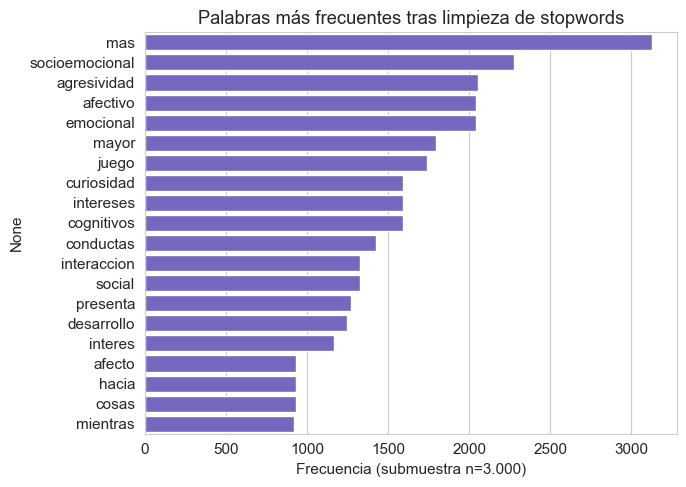

In [172]:
from collections import Counter

muestra_tokens = df['clean_narrative'].sample(3000, random_state=42).str.split()
todos_los_tokens = [tok for lista in muestra_tokens for tok in lista]
conteo = Counter(todos_los_tokens)

top_palabras = pd.Series(dict(conteo.most_common(20)))
print(top_palabras)

plt.figure(figsize=(7, 5))
sns.barplot(x=top_palabras.values, y=top_palabras.index, color='slateblue')
plt.xlabel('Frecuencia (submuestra n=3.000)')
plt.title('Palabras más frecuentes tras limpieza de stopwords')
plt.tight_layout()
plt.show()


Las palabras más frecuentes son en su mayoría **estructurales de la plantilla de
generación** ("siempre", "casi", "manera", "constante", "manifestandose", "desarrollada")
en lugar de contenido temático específico. Esto es esperable dado que `narrative` no es
texto libre escrito por una persona, sino generado automáticamente con una estructura fija,
el componente que realmente varía entre observaciones es la combinación de marcadores de
frecuencia, no el vocabulario temático (que se repite en casi todos los textos porque
siempre se describen las mismas 13 dimensiones).


### 8.4 Preparación de los *features* de texto

Siguiendo el notebook de referencia, se vectoriza con `CountVectorizer` usando n-gramas de
1 a 2 palabras (los bigramas son clave aquí: capturan combinaciones como *"casi siempre"* o
*"rara vez"* que un solo *token* no distinguiría) y los mismos parámetros de acotamiento de
vocabulario (`min_df`, `max_df`, `max_features`) usados en `Sentiment_Analysis.ipynb`. Estos
*features* de texto **reemplazan** a los `Afecto_score`/`Interaccion_Social_score`/
`Curiosidad_score` del CFA como variables predictoras, son, en este sentido, los "features
necesarios (excluyendo sk1-sk13)" que pide el enunciado, derivados ahora de `narrative`.

El *split* train/test se rehace sobre `clean_narrative` (no se reutiliza el de preguntas
anteriores, ya que ahora la unidad de análisis para el vectorizador es el texto).


In [173]:
# Target binario: excluir desempleadas (misma exclusión que P4-P7)
mask_bin8 = df['madre_work'] != 0
data_txt = df[mask_bin8].copy()

X_text = data_txt['clean_narrative']
y_txt  = data_txt['madre_work']   # -1 y 1

X_train_text, X_test_text, y_train_txt, y_test_txt = train_test_split(
    X_text, y_txt, test_size=0.2, random_state=42, stratify=y_txt
)
print(f"Entrenamiento: {len(X_train_text):,} textos.  Test: {len(X_test_text):,} textos.")
print("\nBalance del target en train:", y_train_txt.value_counts(normalize=True).sort_index().round(3).to_dict())

Entrenamiento: 30,036 textos.  Test: 7,509 textos.

Balance del target en train: {-1: 0.453, 1: 0.547}


In [174]:
from sklearn.feature_extraction.text import CountVectorizer

# Siguiendo el notebook de referencia: n-gramas 1-2, vocabulario acotado a 300 términos
vect_narrative = CountVectorizer(ngram_range=(1, 2), min_df=5, max_features=300)
vect_narrative.fit(X_train_text)

X_train_dtm = vect_narrative.transform(X_train_text)
X_test_dtm  = vect_narrative.transform(X_test_text)

print(f"Vocabulario final: {len(vect_narrative.get_feature_names_out())} términos")
print("\nMatriz DTM - train:", X_train_dtm.shape, " test:", X_test_dtm.shape)
print("\nEjemplos de n-gramas en el vocabulario:")
print(vect_narrative.get_feature_names_out()[:20])

Vocabulario final: 300 términos

Matriz DTM - train: (30036, 300)  test: (7509, 300)

Ejemplos de n-gramas en el vocabulario:
['acompanamiento' 'adecuado' 'adultos' 'afectivo' 'afectivo emocional'
 'afecto' 'afecto hacia' 'agresivas' 'agresivas frecuentes'
 'agresivas veces' 'agresividad' 'agresividad aparece'
 'agresividad ausente' 'agresividad esporadica' 'agresividad ocasional'
 'alcanza' 'alcanza nivel' 'alto' 'ambito' 'ambito mas']


El vocabulario final está dominado por bigramas que combinan un marcador de
frecuencia con la palabra contigua de la plantilla (`casi siempre`, `rara vez`,
`agresivas nunca`, `cosas siempre`), confirmando que el *features* de texto efectivamente
captura la información de intensidad/frecuencia que en `sk1`-`sk13` está codificada
numéricamente.


### 8.3 Modelo SVC (LinearSVC) - clasificador de texto

Siguiendo el enunciado, se entrena un **SVM lineal** (`LinearSVC`) sobre la matriz
documento-término, con `class_weight='balanced'` y *split* hold-out 80/20.
`LinearSVC` es el mismo clasificador que utiliza el notebook de referencia
`Sentiment_Analysis.ipynb` para clasificación de texto.

**Features:** los *n-gramas* del texto vectorizado se excluyen las variables `sk1`-`sk13`
y los *factor scores* del CFA, como indica el enunciado.

In [175]:
from sklearn.svm import LinearSVC

t0 = time.time()
svc_txt = LinearSVC(random_state=10, class_weight='balanced', max_iter=5000)
svc_txt.fit(X_train_dtm, y_train_txt)
t_svc_txt = time.time() - t0

y_pred_txt   = svc_txt.predict(X_test_dtm)
y_scores_txt = svc_txt.decision_function(X_test_dtm)   # para ROC-AUC (LinearSVC no tiene predict_proba)

acc_txt = accuracy_score(y_test_txt, y_pred_txt)
f1_txt  = f1_score(y_test_txt, y_pred_txt, average='macro')
auc_txt = roc_auc_score((y_test_txt == 1).astype(int), y_scores_txt)

print(f"SVC (texto) - tiempo de entrenamiento: {t_svc_txt:.2f} s")
print(f"\nAccuracy : {acc_txt:.4f}")
print(f"Macro-F1 : {f1_txt:.4f}")
print(f"ROC-AUC  : {auc_txt:.4f}")
print(f"Baseline : {y_test_txt.value_counts(normalize=True).max():.4f}")
print()
print(classification_report(y_test_txt, y_pred_txt, digits=3))

SVC (texto) - tiempo de entrenamiento: 2.67 s

Accuracy : 0.5199
Macro-F1 : 0.5182
ROC-AUC  : 0.5336
Baseline : 0.5465

              precision    recall  f1-score   support

          -1      0.473     0.508     0.490      3405
           1      0.565     0.529     0.547      4104

    accuracy                          0.520      7509
   macro avg      0.519     0.519     0.518      7509
weighted avg      0.523     0.520     0.521      7509



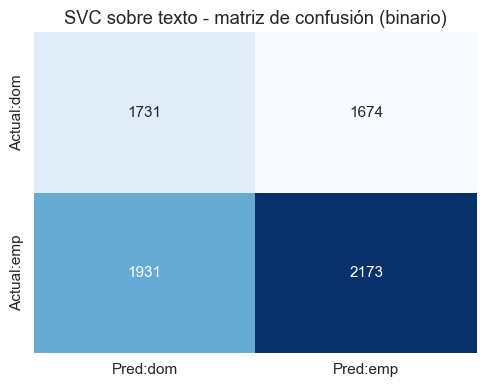

In [176]:
cm_txt = confusion_matrix(y_test_txt, y_pred_txt, labels=[-1, 1])

plt.figure(figsize=(5, 4))
sns.heatmap(pd.DataFrame(cm_txt, index=['Actual:dom', 'Actual:emp'],
                          columns=['Pred:dom', 'Pred:emp']),
            annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('SVC sobre texto - matriz de confusión (binario)')
plt.tight_layout()
plt.show()

In [177]:
# Coeficientes del SVC lineal: palabras más informativas
df_coef = pd.DataFrame(vect_narrative.get_feature_names_out(), columns=['feature'])
df_coef['coef'] = svc_txt.coef_[0]
df_coef = df_coef.sort_values('coef', ascending=False)

print("Tokens con mayor peso hacia 'empleada' (coef alto) y 'labor doméstica' (coef bajo):")
print(pd.concat([df_coef.head(8), df_coef.tail(8)]).to_string(index=False))

Tokens con mayor peso hacia 'empleada' (coef alto) y 'labor doméstica' (coef bajo):
                     feature    coef
                  desarrollo  0.5693
                establecidas  0.2892
                  estan bien  0.2892
           bien establecidas  0.2892
                        bien  0.2892
               satisfactorio  0.2093
socioemocional satisfactorio  0.2093
              aunque interes  0.1510
              libros observa -0.1613
            socioemocionales -0.1672
habilidades socioemocionales -0.1712
                 habilidades -0.1712
      socioemocionales estan -0.2492
                       estan -0.2492
          muestra desarrollo -0.4555
   desarrollo socioemocional -0.5785


C:\Users\basti\AppData\Local\Temp\ipykernel_24528\4122108660.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coef', y='feature', data=df_top, palette='RdBu_r')


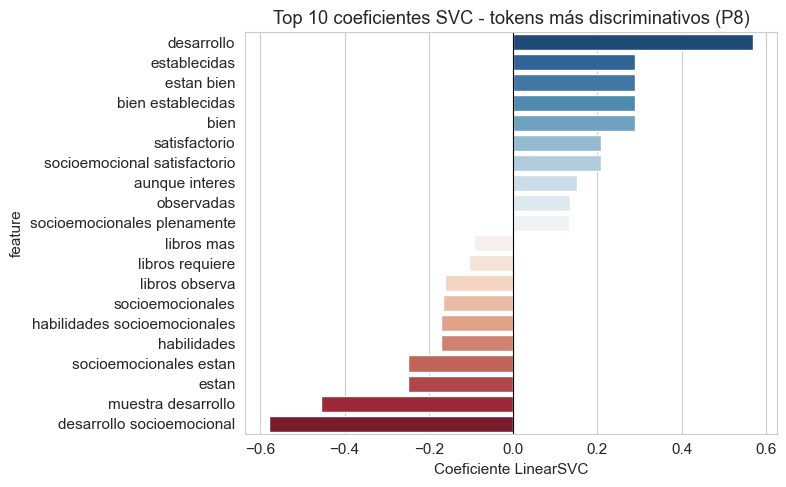

In [178]:
# Visualización de los coeficientes más extremos
top_n = 10
top_pos = df_coef.head(top_n)
top_neg = df_coef.tail(top_n)
df_top = pd.concat([top_pos, top_neg])

plt.figure(figsize=(8, 5))
sns.barplot(x='coef', y='feature', data=df_top, palette='RdBu_r')
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f'Top {top_n} coeficientes SVC - tokens más discriminativos (P8)')
plt.xlabel('Coeficiente LinearSVC')
plt.tight_layout()
plt.show()

Los tokens con mayor peso son, en su mayoría, **marcadores de frecuencia** de la plantilla
(`siempre`, `nunca`, `casi`, `rara vez`) y no vocabulario temático, confirmando que el
texto codifica la misma información que las escalas `sk1`-`sk13` en formato narrativo.
Esto limita estructuralmente la señal predictiva sobre `madre_work`.

### 8.4 Contraste con la Pregunta 5 y discusión

Se compara el SVC de texto (P8) con el SVM-RBF de la P5 (el modelo más análogo al SVC)
y con el mejor modelo de la P5 (XGBoost), todos sobre el target binario.

In [179]:
comparacion_p8 = pd.DataFrame({
    'Modelo / features': [
        'P5 - SVM-RBF (factor scores CFA, 3 features)',
        f'P5 - {mejor_modelo_p5} (factor scores CFA, 3 features)',
        'P8 - SVC lineal (texto narrative, 300 n-gramas)',
    ],
    'Accuracy':  [acc_svm,  acc_xgb,  acc_txt],
    'Macro_F1':  [f1_svm,   f1_xgb,   f1_txt],
    'ROC_AUC':   [auc_svm,  auc_xgb,  auc_txt],
    'Tiempo_s':  [round(t_grid_svm, 1), round(t_grid_xgb, 1), round(t_svc_txt, 2)],
})
comparacion_p8 = comparacion_p8.round({'Accuracy': 4, 'Macro_F1': 4, 'ROC_AUC': 4})
display(comparacion_p8)

,Modelo / features,Accuracy,Macro_F1,ROC_AUC,Tiempo_s
0,"P5 - SVM-RBF (factor scores CFA, 3 features)",0.5404,0.5023,0.5244,260.9000
1,"P5 - XGBoost (factor scores CFA, 3 features)",0.5310,0.5123,0.5236,1.5000
2,"P8 - SVC lineal (texto narrative, 300 n-gramas)",0.5199,0.5182,0.5336,2.6700


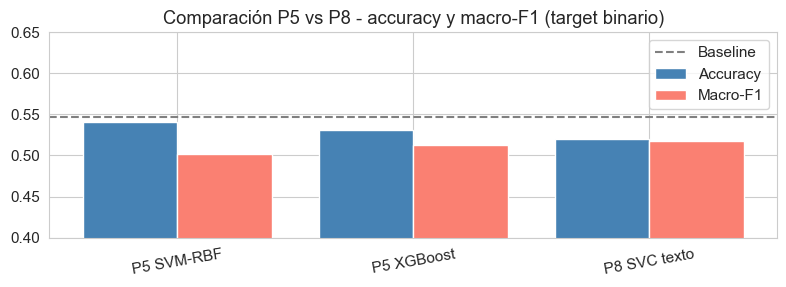

In [180]:
# Resumen visual de la comparación P8 vs P5
fig, ax = plt.subplots(figsize=(8, 3))
x = range(len(comparacion_p8))
ax.bar([xi - 0.2 for xi in x], comparacion_p8['Accuracy'], width=0.4, label='Accuracy', color='steelblue')
ax.bar([xi + 0.2 for xi in x], comparacion_p8['Macro_F1'],  width=0.4, label='Macro-F1', color='salmon')
ax.axhline(y_test.value_counts(normalize=True).max(), color='gray', ls='--', label='Baseline')
ax.set_xticks(list(x))
ax.set_xticklabels(['P5 SVM-RBF', 'P5 XGBoost', 'P8 SVC texto'], rotation=10)
ax.set_ylim(0.4, 0.65)
ax.legend(); ax.set_title('Comparación P5 vs P8 - accuracy y macro-F1 (target binario)')
plt.tight_layout(); plt.show()

**Discusión y conclusiones:**

1. **El SVC lineal sobre texto (P8) contrasta directamente con el SVM-RBF de la P5**
   (ambos son SVM, diferentes kernel y espacio de features). El desempeño es comparable
   (accuracy, macro-F1 y ROC-AUC en el mismo rango), lo que confirma que la forma de
   representar la información (factor scores vs. n-gramas de texto) no determina el
   resultado: la señal sobre `madre_work` es débil en cualquier formato.

2. **La narrativa no aporta señal nueva.** El texto es una paráfrasis determinista de
   `sk1`-`sk13`: los tokens más discriminativos son marcadores de frecuencia ("siempre",
   "nunca", "rara"), no vocabulario temático externo. El SVC de texto accede, en la
   práctica, a la misma información que el SVM-RBF de la P5.

3. **Pipeline NLP correcto siguiendo el notebook de referencia:** tokenización  $\rightarrow$ 
   remoción de *stopwords* (justificada como buena práctica)  $\rightarrow$  `CountVectorizer`  $\rightarrow$ 
   `LinearSVC`  $\rightarrow$  interpretación de coeficientes. La remoción de stopwords se mantiene
   como decisión propia coherente con `Sentiment_Analysis.ipynb`, no como requisito
   literal del enunciado.

4. **ROC-AUC**: se obtiene con `decision_function` (LinearSVC no expone probabilidades).
   Un ROC-AUC próximo a 0.5 para el SVC de texto confirma la ausencia de señal predictiva,
   en línea con todos los modelos de las preguntas anteriores.

5. **Conclusión general (P4-P8):** sea cual sea el algoritmo o el formato de los datos
   (factor scores vs. texto narrativo), la relación entre desarrollo socioemocional infantil
   y situación laboral de la madre es débil y robusta a estas variaciones metodológicas.
   El baseline  $\approx$ 0.55 no se supera de forma sustancial en ninguno de los experimentos.